In [ ]:
import os 
import torch
# torch.autograd.set_detect_anomaly(True)


# # CLASSES_FILE = r'data\archive\class_names.txt
CLASSES_FILE = r'C:\Users\Sistem Cerdas Five\Desktop\vian\afre\lesgo\LoLI-Street Dataset\YOLO Annotations\Train\high\Classes\class_names.txt'
BATCH_SIZE=8 
IMG_SIZE=(640, 640)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
from modules.data_obj import LoLiStreetDataset_Curated
from torch.utils.data import DataLoader
import torchvision.transforms as T
import pandas as pd 


# train_root = r'C:\Users\vian8\Desktop\Tugas2\LLIE\LoLI-Street Dataset\LoLI-Street Dataset\Train'
# val_root = r'C:\Users\vian8\Desktop\Tugas2\LLIE\LoLI-Street Dataset\LoLI-Street Dataset\Val'

train_root = r'C:\Users\Sistem Cerdas Five\Desktop\vian\afre\lesgo\LoLI-Street Dataset\Train'
val_root = r'C:\Users\Sistem Cerdas Five\Desktop\vian\afre\lesgo\LoLI-Street Dataset\Val'

# train_GT_root = r'C:\Users\vian8\Desktop\Tugas2\LLIE\LoLI-Street Dataset\LoLI-Street Dataset\YOLO Annotations\Train'
# val_GT_root = r'C:\Users\vian8\Desktop\Tugas2\LLIE\LoLI-Street Dataset\LoLI-Street Dataset\YOLO Annotations\Val'

train_GT_root = r'C:\Users\Sistem Cerdas Five\Desktop\vian\afre\lesgo\LoLI-Street Dataset\YOLO Annotations\Train'
val_GT_root = r'C:\Users\Sistem Cerdas Five\Desktop\vian\afre\lesgo\LoLI-Street Dataset\YOLO Annotations\Val'

# train_curated_pth = r'C:\Users\vian8\Desktop\Tugas2\LLIE\LoLI-Street Dataset\LoLI-Street Dataset\curated_dataset.csv'
# val_curated_pth = r'C:\Users\vian8\Desktop\Tugas2\LLIE\LoLI-Street Dataset\LoLI-Street Dataset\val_curated_dataset.csv'

train_curated_pth = r'C:\Users\Sistem Cerdas Five\Desktop\vian\afre\lesgo\New folder\curated_dataset.csv'
val_curated_pth = r'C:\Users\Sistem Cerdas Five\Desktop\vian\afre\lesgo\New folder\val_curated_dataset.csv'

# Define paths for the new split files
# val_split_pth = r'C:\Users\vian8\Desktop\Tugas2\LLIE\LoLI-Street Dataset\LoLI-Street Dataset\val_split.csv'
# test_split_pth = r'C:\Users\vian8\Desktop\Tugas2\LLIE\LoLI-Street Dataset\LoLI-Street Dataset\test_split.csv'

val_split_pth = r'C:\Users\Sistem Cerdas Five\Desktop\vian\afre\lesgo\New folder\val_split.csv'
test_split_pth = r'C:\Users\Sistem Cerdas Five\Desktop\vian\afre\lesgo\New folder\test_split.csv'

# 1. Load the original 200-row CSV
df_val_full = pd.read_csv(val_curated_pth)

# 2. Shuffle the rows 
# Using random_state=42 ensures you get the exact same split every time you run this script
df_shuffled = df_val_full.sample(frac=1, random_state=42).reset_index(drop=True)

# 3. Split down the middle (100 and 100)
df_val_final = df_shuffled.iloc[:100]
df_test_final = df_shuffled.iloc[100:]

# 4. Save the new splits
df_val_final.to_csv(val_split_pth, index=False)
df_test_final.to_csv(test_split_pth, index=False)

print(f"Created Val Split: {len(df_val_final)} scenes")
print(f"Created Test Split: {len(df_test_final)} scenes")

try:
    data_transform = T.ToTensor() 

    print("Initializing Train Dataset...")
    train_dataset = LoLiStreetDataset_Curated(
        csv_path=train_curated_pth,
        high_dir=os.path.join(train_root, 'high'), 
        low_dir=os.path.join(train_root, 'low'), 
        high_gt_dir=os.path.join(train_GT_root, 'high/Labels'),
        low_gt_dir=os.path.join(train_GT_root, 'low/Labels')
    )
    
    print("Initializing Val Dataset...")
    val_dataset = LoLiStreetDataset_Curated(
        csv_path=val_split_pth,
        high_dir=os.path.join(val_root, 'high'), 
        low_dir=os.path.join(val_root, 'low'), 
        high_gt_dir=os.path.join(val_GT_root, 'YOLO Annotations (high)/Labels'),
        low_gt_dir=os.path.join(val_GT_root, 'YOLO Annotations (low)/Labels')
    )

    print("Initializing Val Dataset...")
    test_dataset = LoLiStreetDataset_Curated(
        csv_path=test_split_pth,
        high_dir=os.path.join(val_root, 'high'), 
        low_dir=os.path.join(val_root, 'low'), 
        high_gt_dir=os.path.join(val_GT_root, 'YOLO Annotations (high)/Labels'),
        low_gt_dir=os.path.join(val_GT_root, 'YOLO Annotations (low)/Labels')
    )
    
    # Create DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=LoLiStreetDataset_Curated.collate_fn, num_workers=0, pin_memory=True)#, persistent_workers=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=LoLiStreetDataset_Curated.collate_fn, num_workers=0, pin_memory=True)#, persistent_workers=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=LoLiStreetDataset_Curated.collate_fn, num_workers=0, pin_memory=True)#, persistent_workers=True)

    print(f"\nSUCCESS: Datasets created. Train size: {len(train_dataset)}")

except Exception as e:
    print(f"\n[ERROR] Failed to initialize datasets: {e}")

Created Val Split: 100 scenes
Created Test Split: 100 scenes
Initializing Train Dataset...
Parsing CSV... Found 1700 curated scenes.
Dataset Built! Expanded to 5100 total image-label pairs.
Initializing Val Dataset...
Parsing CSV... Found 100 curated scenes.
Dataset Built! Expanded to 300 total image-label pairs.
Initializing Val Dataset...
Parsing CSV... Found 100 curated scenes.
Dataset Built! Expanded to 300 total image-label pairs.

SUCCESS: Datasets created. Train size: 5100


In [3]:

def run_sanity_check(dataset, scenes_to_check=2):
    print(f"Total Dataset Size: {len(dataset)} pairs")
    print("=" * 60)
    
    # We check scenes_to_check * 3 because there are 3 illumination variants per scene
    items_to_check = min(scenes_to_check * 3, len(dataset))
    
    for i in range(items_to_check):
        # 1. Check the raw file paths we stored in the lists
        low_img_path = dataset.low_images[i]
        high_img_path = dataset.high_images[i]
        label_file_path = dataset.labels_files[i]
        
        # 2. Pull the actual item to make sure __getitem__ runs smoothly
        data = dataset[i]
        num_bboxes = data['bboxes'].shape[0]
        
        print(f"Dataset Index [{i}]:")
        print(f"  Low Input:  {os.path.basename(low_img_path)}")
        print(f"  High Target:{os.path.basename(high_img_path)}")
        print(f"  GT Label:   {os.path.basename(label_file_path)} ---> ({num_bboxes} boxes loaded)")
        
        # Print a divider after every 3rd image (end of a scene triplet)
        if (i + 1) % 3 == 0:
            print("-" * 60)

# Run it!
# run_sanity_check(train_dataset, scenes_to_check=2)
# run_sanity_check(val_dataset, scenes_to_check=2)
# run_sanity_check(test_dataset, scenes_to_check=2)

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches


# def visualize_dataset_sample(dataset, index=0):
#     # 1. Fetch the data dictionary from the dataset
#     data = dataset[index]
    
#     # 2. Extract tensors
#     img_low_tensor = data['images_low']
#     img_high_tensor = data['images_high']
#     bboxes = data['bboxes']
#     classes = data['cls']
#     im_id = data['im_id']
    
#     # 3. Convert tensors [C, H, W] back to numpy arrays [H, W, C] for matplotlib
#     # Since they were divided by 255.0, they are in the [0, 1] range, which plt.imshow handles natively
#     img_low_np = img_low_tensor.permute(1, 2, 0).numpy()
#     img_high_np = img_high_tensor.permute(1, 2, 0).numpy()
    
#     # Get the actual dimensions of the padded tensor (e.g., 640x640)
#     tensor_h, tensor_w = img_low_np.shape[:2]
    
#     # 4. Setup the plot
#     fig, axs = plt.subplots(1, 2, figsize=(16, 8))
#     fig.suptitle(f"Sanity Check: Adjusted Bboxes on Padded Tensors | Image ID: {im_id}", fontsize=16)
    
#     for ax, img, title in zip(axs, [img_low_np, img_high_np], ["Low Input", "High Target (Ground Truth)"]):
#         ax.imshow(img)
#         ax.set_title(title)
#         ax.axis('off')
        
#         # 5. Draw the bounding boxes
#         for i in range(len(bboxes)):
#             # YOLO format is normalized [x_center, y_center, width, height]
#             x_c, y_c, w, h = bboxes[i].numpy()
#             cls_id = classes[i].item()
            
#             # Convert normalized relative coordinates back to absolute pixel coordinates
#             abs_x_c = x_c * tensor_w
#             abs_y_c = y_c * tensor_h
#             abs_w = w * tensor_w
#             abs_h = h * tensor_h
            
#             # Matplotlib Rectangle needs the top-left corner
#             top_left_x = abs_x_c - (abs_w / 2)
#             top_left_y = abs_y_c - (abs_h / 2)
            
#             # Create the rectangle patch
#             rect = patches.Rectangle(
#                 (top_left_x, top_left_y), abs_w, abs_h, 
#                 linewidth=2, edgecolor='lime', facecolor='none'
#             )
#             ax.add_patch(rect)
            
#             # Optional: Add class label text
#             ax.text(top_left_x, top_left_y - 5, f'Class {cls_id}', 
#                     color='black', backgroundcolor='lime', fontsize=9, weight='bold')
            
#     plt.tight_layout()
#     plt.show()

def visualize_dataset_sample(dataset, index=0):
    # 1. Fetch the data dictionary from the dataset
    data = dataset[index]
    
    # 2. Extract tensors
    img_low_tensor = data['images_low']
    img_high_tensor = data['images_high']
    bboxes = data['bboxes']
    classes = data['cls']
    im_id = data['im_id']
    
    # 3. Convert tensors [C, H, W] back to numpy arrays [H, W, C] for matplotlib
    img_low_np = img_low_tensor.permute(1, 2, 0).numpy()
    img_high_np = img_high_tensor.permute(1, 2, 0).numpy()
    
    # Get the actual dimensions of the padded tensor
    tensor_h, tensor_w = img_low_np.shape[:2]
    
    # --- NEW: Print the exact image and tensor sizes ---
    print(f"\n--- Sanity Check: Index {index} | Image ID: {im_id} ---")
    print(f"Low Tensor Shape  [C, H, W]: {list(img_low_tensor.shape)}")
    print(f"High Tensor Shape [C, H, W]: {list(img_high_tensor.shape)}")
    print(f"Padded Resolution (H x W): {tensor_h} x {tensor_w}")
    print(f"Total Bounding Boxes     : {len(bboxes)}")
    print("-" * 45 + "\n")
    
    # 4. Setup the plot
    fig, axs = plt.subplots(1, 2, figsize=(16, 8))
    fig.suptitle(f"Sanity Check: Adjusted Bboxes on Padded Tensors | Image ID: {im_id}", fontsize=16)
    
    for ax, img, title in zip(axs, [img_low_np, img_high_np], ["Low Input", "High Target (Ground Truth)"]):
        ax.imshow(img)
        ax.set_title(title)
        ax.axis('off')
        
        # 5. Draw the bounding boxes
        for i in range(len(bboxes)):
            # YOLO format is normalized [x_center, y_center, width, height]
            x_c, y_c, w, h = bboxes[i].numpy()
            cls_id = classes[i].item()
            
            # Convert normalized relative coordinates back to absolute pixel coordinates
            abs_x_c = x_c * tensor_w
            abs_y_c = y_c * tensor_h
            abs_w = w * tensor_w
            abs_h = h * tensor_h
            
            # Matplotlib Rectangle needs the top-left corner
            top_left_x = abs_x_c - (abs_w / 2)
            top_left_y = abs_y_c - (abs_h / 2)
            
            # Create the rectangle patch
            rect = patches.Rectangle(
                (top_left_x, top_left_y), abs_w, abs_h, 
                linewidth=2, edgecolor='lime', facecolor='none'
            )
            ax.add_patch(rect)
            
            # Optional: Add class label text
            ax.text(top_left_x, top_left_y - 5, f'Class {cls_id}', 
                    color='black', backgroundcolor='lime', fontsize=9, weight='bold')
            
    plt.tight_layout()
    plt.show()

# visualize_dataset_sample(test_dataset, index=0)  
# visualize_dataset_sample(test_dataset, index=1)  
# visualize_dataset_sample(test_dataset, index=2)  

In [5]:
from models.illuminet import Enh_Dec_Net, YOLOv8_Clone


baseline_enh = Enh_Dec_Net(back_use_arb=False, dec_arb=False)
backARB_enh = Enh_Dec_Net(back_use_arb=True, dec_arb=False)
decARB_enh = Enh_Dec_Net(back_use_arb=False, dec_arb=True)
bothARB_enh = Enh_Dec_Net(back_use_arb=True, dec_arb=True)

355
Backbone ARB:  False
Decoder ARB False
Initializing nano params
NO ARB in Backbone
Night Dec initalized
✅ Loaded 162 layers into Backbone.
Missing keys: 0 | Unexpected keys: 0
pretrain weights loaded
Backbone ARB:  True
Decoder ARB False
Initializing nano params
ARB Backbone Initialized
Night Dec initalized
✅ Loaded 162 layers into Backbone.
Missing keys: 72 | Unexpected keys: 0
pretrain weights loaded
Backbone ARB:  False
Decoder ARB True
Initializing nano params
NO ARB in Backbone
ARB LLIE Decoder Initialized
✅ Loaded 162 layers into Backbone.
Missing keys: 0 | Unexpected keys: 0
pretrain weights loaded
Backbone ARB:  True
Decoder ARB True
Initializing nano params
ARB Backbone Initialized
ARB LLIE Decoder Initialized
✅ Loaded 162 layers into Backbone.
Missing keys: 72 | Unexpected keys: 0
pretrain weights loaded


In [6]:
print(f"baseline_enh params: {sum(p.numel() for p in baseline_enh.parameters())/1e6} million parameters")
print(f"backARB_enh params: {sum(p.numel() for p in backARB_enh.parameters())/1e6} million parameters")
print(f"decARB_enh params: {sum(p.numel() for p in decARB_enh.parameters())/1e6} million parameters")
print(f"bothARB_enh params: {sum(p.numel() for p in bothARB_enh.parameters())/1e6} million parameters")
print()

yol_back = YOLOv8_Clone(back_use_arb=True)
print(f"yol_back params: {sum(p.numel() for p in yol_back.parameters())/1e6} million parameters")


baseline_enh params: 1.491611 million parameters
backARB_enh params: 4.672447 million parameters
decARB_enh params: 1.886277 million parameters
bothARB_enh params: 5.067113 million parameters

Initializing nano params
ARB Backbone Initialized
Initializing nano params
Initializing nano params
✅ Loaded 162 layers into Backbone.
Missing keys: 72 | Unexpected keys: 0
✅ Loaded 108 layers into Neck.
Missing keys: 0 | Unexpected keys: 0
✅ Loaded 85 layers into Head.
Missing keys: 0 | Unexpected keys: 0
yol_back params: 6.338036 million parameters


In [7]:
from training.train import EnhancementTrainer
from losses.yolo_loss import DetectionLoss
from losses.llie_loss import mean_abs_error


backARB_enh = Enh_Dec_Net(back_use_arb=True, dec_arb=False)

backARB_enh_trainer = EnhancementTrainer(
    model=backARB_enh,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=60,
    enhance_loss_fn=mean_abs_error,
    experiment_name='backARB_enh_net',
    # device=DEVICE
)

training_hist = backARB_enh_trainer.fit()
df_hist = pd.DataFrame(training_hist)
df_hist.to_csv('training_backARB_enh.csv', index=False)

Backbone ARB:  True
Decoder ARB False
Initializing nano params
ARB Backbone Initialized
Night Dec initalized
✅ Loaded 162 layers into Backbone.
Missing keys: 72 | Unexpected keys: 0
pretrain weights loaded
Starting Enhancement Training on cuda for 60 epochs...


Epoch 0/60: 100%|██████████| 638/638 [02:31<00:00,  4.21it/s, Loss=0.0470, LR_Back=1.04e-05, LR_Dec=1.04e-04]


*** New Best PSNR: 21.42 -> Saved best_backARB_enh_net_psnr.pt ***

--- Epoch 0 Summary (151.60s) ---
Train Loss: 0.1043 | Val Loss: 0.0516
Enhancement: PSNR=21.42 | SSIM=0.746
-------------------------------------------



Epoch 1/60: 100%|██████████| 638/638 [01:30<00:00,  7.06it/s, Loss=0.0365, LR_Back=2.80e-05, LR_Dec=2.80e-04]


*** New Best PSNR: 25.80 -> Saved best_backARB_enh_net_psnr.pt ***

--- Epoch 1 Summary (90.43s) ---
Train Loss: 0.0418 | Val Loss: 0.0297
Enhancement: PSNR=25.80 | SSIM=0.861
-------------------------------------------



...

Epoch 58/60: 100%|██████████| 638/638 [01:34<00:00,  6.72it/s, Loss=0.0171, LR_Back=8.47e-08, LR_Dec=8.47e-07]



--- Epoch 58 Summary (94.89s) ---
Train Loss: 0.0132 | Val Loss: 0.0163
Enhancement: PSNR=30.46 | SSIM=0.936
-------------------------------------------



Epoch 59/60: 100%|██████████| 638/638 [01:35<00:00,  6.70it/s, Loss=0.0144, LR_Back=4.00e-10, LR_Dec=4.00e-09]
                                                                           


--- Epoch 59 Summary (95.28s) ---
Train Loss: 0.0132 | Val Loss: 0.0162
Enhancement: PSNR=30.53 | SSIM=0.924
-------------------------------------------



NameError: name 'pd' is not defined

In [5]:
def visualize_train_plots(training_hist): # Extract data
    epochs = [h['epoch'] for h in training_hist]
    train_loss = [h['train_loss_total'] for h in training_hist]
    val_loss = [h['val_loss_total'] for h in training_hist]

    val_map50 = [h['val_mAP50'] for h in training_hist]
    val_prec_prox = [h['val_prec_prox'] for h in training_hist]
    val_recall = [h['val_recall'] for h in training_hist]

    val_psnr = [h['val_psnr'] for h in training_hist]
    val_ssim = [h['val_ssim'] for h in training_hist]

    # Set up the figure with 3 subplots
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('IllumiNet Multi-Task Training Progress', fontsize=16, fontweight='bold')

    # --- Plot 1: Total Loss ---
    axs[0].plot(epochs, train_loss, label='Train Loss', color='tab:blue', marker='o', linewidth=2)
    axs[0].plot(epochs, val_loss, label='Validation Loss', color='tab:orange', marker='s', linewidth=2)
    axs[0].set_title('Total Loss Convergence')
    axs[0].set_xlabel('Epoch')
    axs[0].set_ylabel('Loss')
    axs[0].set_xticks(epochs)
    axs[0].grid(True, linestyle='--', alpha=0.6)
    axs[0].legend()

    # --- Plot 2: Detection Metrics ---
    axs[1].plot(epochs, val_map50, label='mAP@0.5', color='tab:green', marker='o', linewidth=2)
    axs[1].plot(epochs, val_prec_prox, label='Precision', color='tab:red', marker='^', linewidth=2) # Added Precision
    axs[1].plot(epochs, val_recall, label='Recall', color='tab:purple', marker='s', linewidth=2)
    axs[1].set_title('YOLO Detection Performance')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Score')
    axs[1].set_xticks(epochs)
    axs[1].grid(True, linestyle='--', alpha=0.6)
    axs[1].legend()

    # --- Plot 3: Enhancement Metrics (Dual Axis) ---
    ax3 = axs[2]
    ax3_twin = ax3.twinx()

    line1 = ax3.plot(epochs, val_psnr, label='PSNR (dB)', color='tab:red', marker='o', linewidth=2)
    line2 = ax3_twin.plot(epochs, val_ssim, label='SSIM', color='tab:brown', marker='s', linewidth=2)

    ax3.set_title('LLIE Enhancement Performance')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('PSNR (dB)', color='tab:red')
    ax3_twin.set_ylabel('SSIM', color='tab:brown')
    ax3.set_xticks(epochs)
    ax3.grid(True, linestyle='--', alpha=0.6)

    # Combine legends for the dual axis
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax3.legend(lines, labels, loc='lower right')

    plt.tight_layout()
    plt.show()
    

visualize_train_plots(training_hist=training_hist)

NameError: name 'training_hist' is not defined

In [7]:
from training.train import DynamicWeightingModelTrainer
from losses.yolo_loss import DetectionLoss
from losses.llie_loss import mean_abs_error

def visualize_train_plots(training_hist): # Extract data
    epochs = [h['epoch'] for h in training_hist]
    train_loss = [h['train_loss_total'] for h in training_hist]
    val_loss = [h['val_loss_total'] for h in training_hist]

    val_map50 = [h['val_mAP50'] for h in training_hist]
    val_prec_prox = [h['val_prec_prox'] for h in training_hist]
    val_recall = [h['val_recall'] for h in training_hist]

    val_psnr = [h['val_psnr'] for h in training_hist]
    val_ssim = [h['val_ssim'] for h in training_hist]

    # Set up the figure with 3 subplots
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('IllumiNet Multi-Task Training Progress', fontsize=16, fontweight='bold')

    # --- Plot 1: Total Loss ---
    axs[0].plot(epochs, train_loss, label='Train Loss', color='tab:blue', marker='o', linewidth=2)
    axs[0].plot(epochs, val_loss, label='Validation Loss', color='tab:orange', marker='s', linewidth=2)
    axs[0].set_title('Total Loss Convergence')
    axs[0].set_xlabel('Epoch')
    axs[0].set_ylabel('Loss')
    axs[0].set_xticks(epochs)
    axs[0].grid(True, linestyle='--', alpha=0.6)
    axs[0].legend()

    # --- Plot 2: Detection Metrics ---
    axs[1].plot(epochs, val_map50, label='mAP@0.5', color='tab:green', marker='o', linewidth=2)
    axs[1].plot(epochs, val_prec_prox, label='Precision', color='tab:red', marker='^', linewidth=2) # Added Precision
    axs[1].plot(epochs, val_recall, label='Recall', color='tab:purple', marker='s', linewidth=2)
    axs[1].set_title('YOLO Detection Performance')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Score')
    axs[1].set_xticks(epochs)
    axs[1].grid(True, linestyle='--', alpha=0.6)
    axs[1].legend()

    # --- Plot 3: Enhancement Metrics (Dual Axis) ---
    ax3 = axs[2]
    ax3_twin = ax3.twinx()

    line1 = ax3.plot(epochs, val_psnr, label='PSNR (dB)', color='tab:red', marker='o', linewidth=2)
    line2 = ax3_twin.plot(epochs, val_ssim, label='SSIM', color='tab:brown', marker='s', linewidth=2)

    ax3.set_title('LLIE Enhancement Performance')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('PSNR (dB)', color='tab:red')
    ax3_twin.set_ylabel('SSIM', color='tab:brown')
    ax3.set_xticks(epochs)
    ax3.grid(True, linestyle='--', alpha=0.6)

    # Combine legends for the dual axis
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax3.legend(lines, labels, loc='lower right')

    plt.tight_layout()
    plt.show()
    


In [9]:
import pandas as pd 


decARB_enh = Enh_Dec_Net(back_use_arb=False, dec_arb=True)

decARB_enh_trainer = EnhancementTrainer(
    model=decARB_enh,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=60,
    enhance_loss_fn=mean_abs_error,
    experiment_name='decARB_enh_net',
    # device=DEVICE
)

training_hist = decARB_enh_trainer.fit()
df_hist = pd.DataFrame(training_hist)
df_hist.to_csv('training_decARB_enh.csv', index=False)

Backbone ARB:  False
Decoder ARB True
Initializing nano params
NO ARB in Backbone
ARB LLIE Decoder Initialized
✅ Loaded 162 layers into Backbone.
Missing keys: 0 | Unexpected keys: 0
pretrain weights loaded
Starting Enhancement Training on cuda for 60 epochs...


Epoch 0/60: 100%|██████████| 638/638 [02:41<00:00,  3.95it/s, Loss=0.0682, LR_Back=1.04e-05, LR_Dec=1.04e-04]


*** New Best PSNR: 22.89 -> Saved best_decARB_enh_net_psnr.pt ***

--- Epoch 0 Summary (161.46s) ---
Train Loss: 0.1209 | Val Loss: 0.0406
Enhancement: PSNR=22.89 | SSIM=0.764
-------------------------------------------



Epoch 1/60: 100%|██████████| 638/638 [02:41<00:00,  3.96it/s, Loss=0.0281, LR_Back=2.80e-05, LR_Dec=2.80e-04]


*** New Best PSNR: 26.30 -> Saved best_decARB_enh_net_psnr.pt ***

--- Epoch 1 Summary (161.16s) ---
Train Loss: 0.0374 | Val Loss: 0.0267
Enhancement: PSNR=26.30 | SSIM=0.875
-------------------------------------------



...

Epoch 58/60: 100%|██████████| 638/638 [02:37<00:00,  4.04it/s, Loss=0.0135, LR_Back=8.47e-08, LR_Dec=8.47e-07]


*** New Best PSNR: 30.62 -> Saved best_decARB_enh_net_psnr.pt ***

--- Epoch 58 Summary (158.00s) ---
Train Loss: 0.0133 | Val Loss: 0.0153
Enhancement: PSNR=30.62 | SSIM=0.936
-------------------------------------------



Epoch 59/60: 100%|██████████| 638/638 [02:37<00:00,  4.04it/s, Loss=0.0188, LR_Back=4.00e-10, LR_Dec=4.00e-09]
                                                                           


--- Epoch 59 Summary (157.99s) ---
Train Loss: 0.0133 | Val Loss: 0.0164
Enhancement: PSNR=30.41 | SSIM=0.936
-------------------------------------------



NameError: name 'pd' is not defined

In [11]:
import os
import torch
import pandas as pd
from tqdm import tqdm
from losses.llie_loss import psnr, ssim_metric
# Assuming psnr and ssim_metric are already imported in your environment

class EnhanceEvaluator:
    def __init__(self, model, dataloader, device=None):
        self.model = model
        self.dataloader = dataloader
        self.device = device if device else torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
        self.model.to(self.device)
        self.model.eval()

        # Tracking dictionaries
        self.results = {
            'light':    {'psnr': 0.0, 'ssim': 0.0, 'count': 0},
            'moderate': {'psnr': 0.0, 'ssim': 0.0, 'count': 0},
            'dense':    {'psnr': 0.0, 'ssim': 0.0, 'count': 0},
            'total':    {'psnr': 0.0, 'ssim': 0.0, 'count': 0}
        }

    def _get_best_epoch(self, hist_csv_path):
        if not hist_csv_path or not os.path.exists(hist_csv_path): return "N/A"
        try:
            df = pd.read_csv(hist_csv_path)
            # Find max PSNR row
            if 'val_psnr' in df.columns:
                return int(df.loc[df['val_psnr'].idxmax(), 'epoch'])
        except Exception as e:
            print(f"Could not read best epoch from {hist_csv_path}: {e}")
        return "N/A"

    def evaluate(self, weight_path, model_name="Enhancement Model", hist_csv_path=None):
        print(f"\nLoading weights for {model_name} from: {weight_path}")
        self.model.load_state_dict(torch.load(weight_path, map_location=self.device))

        # Reset Trackers
        for illum in ['light', 'moderate', 'dense', 'total']:
            self.results[illum] = {'psnr': 0.0, 'ssim': 0.0, 'count': 0}

        with torch.no_grad():
            for batch in tqdm(self.dataloader, desc=f"Evaluating {model_name}"):
                low_imgs = batch['images_low'].to(self.device)
                high_imgs = batch['images_high'].to(self.device)
                im_ids = batch['im_id']
                B = low_imgs.shape[0]

                # Forward Pass
                with torch.autocast(device_type=self.device.type, enabled=(self.device.type == 'cuda')):
                    # Assumes your LLIE model returns (enhanced_img, residuals)
                    enhanced_imgs, _ = self.model(low_imgs)
                
                # Process metrics per image to categorize by illumination
                for b in range(B):
                    # Identify illumination type
                    illum = 'total'
                    for i_type in ['light', 'moderate', 'dense']:
                        if i_type in im_ids[b].lower():
                            illum = i_type
                            break

                    # Calculate metrics
                    # PSNR expects batched tensors, so we slice [b:b+1] to keep the batch dimension
                    curr_psnr = psnr(enhanced_imgs[b:b+1], high_imgs[b:b+1]).item()
                    
                    # SSIM usually expects single 3D tensors
                    curr_ssim = ssim_metric(enhanced_imgs[b], high_imgs[b])
                    if isinstance(curr_ssim, torch.Tensor): 
                        curr_ssim = curr_ssim.item()

                    # Update specific category
                    self.results[illum]['psnr'] += curr_psnr
                    self.results[illum]['ssim'] += curr_ssim
                    self.results[illum]['count'] += 1
                    
                    # Update total
                    self.results['total']['psnr'] += curr_psnr
                    self.results['total']['ssim'] += curr_ssim
                    self.results['total']['count'] += 1

        # Compute Averages
        def safe_mean(illum, metric):
            count = self.results[illum]['count']
            return self.results[illum][metric] / count if count > 0 else 0.0

        summary = {
            'Weights': os.path.basename(weight_path),
            'PSNR_Avg': safe_mean('total', 'psnr'),
            'SSIM_Avg': safe_mean('total', 'ssim'),
            
            'PSNR_Light': safe_mean('light', 'psnr'),
            'SSIM_Light': safe_mean('light', 'ssim'),
            
            'PSNR_Moderate': safe_mean('moderate', 'psnr'),
            'SSIM_Moderate': safe_mean('moderate', 'ssim'),
            
            'PSNR_Dense': safe_mean('dense', 'psnr'),
            'SSIM_Dense': safe_mean('dense', 'ssim'),
            
            'Best_Epoch': self._get_best_epoch(hist_csv_path)
        }

        print("\n" + "="*50)
        print(" ENHANCEMENT RESULTS ")
        print("="*50)
        for key, value in summary.items():
            if isinstance(value, float): 
                print(f"{key:>20}: {value:.4f}")
            else: 
                print(f"{key:>20}: {value}")
                
        return summary

In [14]:
from models.illuminet import Enh_Dec_Net
import pandas as pd

# ==========================================
# 1. DEFINE CONFIGURATIONS
# ==========================================
enhancement_configs = [
    {
        'name': 'Enh_BackARB',
        'back_use_arb': True,
        'dec_arb': False,
        # 'hist_csv': 'training_hist_llie_only_BackARB.csv', # Match your actual CSV name
        'best_weights': r'C:\Users\Sistem Cerdas Five\Desktop\vian\afre\lesgo\New folder\best_backARB_enh_net_psnr.pt',  # Match your actual weights name
        'final_weights': r'C:\Users\Sistem Cerdas Five\Desktop\vian\afre\lesgo\New folder\final_backARB_enh_net_epoch60.pt'
    },
    # {
    #     'name': 'Enh_DecARB',
    #     'back_use_arb': False,
    #     'dec_arb': True,
    #     'hist_csv': 'training_hist_llie_only_DecARB.csv',
    #     'best_weights': 'best_llie_only_DecARB_psnr.pt',
    #     'final_weights': 'final_llie_only_DecARB_epoch60.pt'
    # }
]

results_list_enh = []

# ==========================================
# 2. RUN EVALUATION
# ==========================================
for cfg in enhancement_configs:
    print("\n" + "="*60)
    print(f" EVALUATING STAGE 1 (ENHANCEMENT): {cfg['name']} ")
    print("="*60)
    
    # Initialize the specific network architecture
    enh_model = Enh_Dec_Net(back_use_arb=cfg['back_use_arb'], dec_arb=cfg['dec_arb'])
    
    # Initialize Evaluator (Pass your original test dataloader)
    evaluator = EnhanceEvaluator(model=enh_model, dataloader=test_loader, device=DEVICE)
    
    if os.path.exists(cfg['best_weights']):
        display_name = f"{cfg['name']} (Best)"
        res_best = evaluator.evaluate(weight_path=cfg['best_weights'], model_name=display_name)
        if res_best:
            res_best['Model'] = display_name
            results_list_enh.append(res_best)

    if os.path.exists(cfg['final_weights']):
        display_name = f"{cfg['name']} (Final)"
        res_final = evaluator.evaluate(weight_path=cfg['final_weights'], model_name=display_name)
        if res_final:
            res_final['Model'] = display_name
            results_list_enh.append(res_final)

# ==========================================
# 3. EXPORT RESULTS
# ==========================================
if results_list_enh:
    df_enh = pd.DataFrame(results_list_enh)
    cols = ['Model'] + [c for c in df_enh.columns if c != 'Model']
    df_enh = df_enh[cols]
    
    print("\n" + "="*80)
    print(" ENHANCEMENT-ONLY RESULTS TABLE ")
    print("="*80)
    print(df_enh.to_string(index=False))
    df_enh.to_csv("Enhancement_Only_Metrics.csv", index=False)

C:\Users\Sistem Cerdas Five\AppData\Local\Temp\ipykernel_12840\2377158339.py:38: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(weight_p


 EVALUATING STAGE 1 (ENHANCEMENT): Enh_BackARB 
Backbone ARB:  True
Decoder ARB False
Initializing nano params
ARB Backbone Initialized
Night Dec initalized
✅ Loaded 162 layers into Backbone.
Missing keys: 72 | Unexpected keys: 0
pretrain weights loaded

Loading weights for Enh_BackARB (Best) from: C:\Users\Sistem Cerdas Five\Desktop\vian\afre\lesgo\New folder\best_backARB_enh_net_psnr.pt


Evaluating Enh_BackARB (Best): 100%|██████████| 38/38 [00:35<00:00,  1.08it/s]



 ENHANCEMENT RESULTS 
             Weights: best_backARB_enh_net_psnr.pt
            PSNR_Avg: 31.2738
            SSIM_Avg: 0.9376184940338135
          PSNR_Light: 33.3420
          SSIM_Light: 0.9618235230445862
       PSNR_Moderate: 31.1287
       SSIM_Moderate: 0.937654435634613
          PSNR_Dense: 29.3507
          SSIM_Dense: 0.9133774638175964
          Best_Epoch: N/A

Loading weights for Enh_BackARB (Final) from: C:\Users\Sistem Cerdas Five\Desktop\vian\afre\lesgo\New folder\final_backARB_enh_net_epoch60.pt


Evaluating Enh_BackARB (Final): 100%|██████████| 38/38 [00:34<00:00,  1.09it/s]


 ENHANCEMENT RESULTS 
             Weights: final_backARB_enh_net_epoch60.pt
            PSNR_Avg: 31.1165
            SSIM_Avg: 0.9229127764701843
          PSNR_Light: 33.0288
          SSIM_Light: 0.9619008898735046
       PSNR_Moderate: 31.1293
       SSIM_Moderate: 0.9375752210617065
          PSNR_Dense: 29.1914
          SSIM_Dense: 0.869263768196106
          Best_Epoch: N/A

 ENHANCEMENT-ONLY RESULTS TABLE 
              Model                          Weights  PSNR_Avg  SSIM_Avg  PSNR_Light  SSIM_Light  PSNR_Moderate  SSIM_Moderate  PSNR_Dense  SSIM_Dense Best_Epoch
 Enh_BackARB (Best)     best_backARB_enh_net_psnr.pt 31.273830  0.937618   33.342017    0.961824      31.128730       0.937654   29.350744    0.913377        N/A
Enh_BackARB (Final) final_backARB_enh_net_epoch60.pt 31.116474  0.922913   33.028765    0.961901      31.129285       0.937575   29.191374    0.869264        N/A


In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import torch

from torchvision.ops import box_iou
import numpy as np
from post_processing.det_postprocess import Detections
from losses.llie_loss import psnr, ssim_metric
from tqdm import tqdm

# 1. Define Robust Precision/Recall Helper
def compute_precision_recall_robust(detections, gt_boxes, iou_thresh=0.5):
    """
    Robust calculation of P/R that handles empty or single-item tensors correctly.
    """
    # A. Prepare Prediction Boxes
    if len(detections) == 0:
        pred_boxes = torch.empty((0, 4))
    else:
        # Convert supervision numpy -> torch
        pred_boxes = torch.from_numpy(detections.xyxy).float()

    # B. Prepare GT Boxes
    gt_boxes = gt_boxes.cpu().float()
    pred_boxes = pred_boxes.cpu()

    # C. SAFETY: Force 2D shapes [N, 4] to prevent box_iou crash on single boxes
    if pred_boxes.dim() == 1: 
        pred_boxes = pred_boxes.unsqueeze(0)
    if gt_boxes.dim() == 1: 
        gt_boxes = gt_boxes.unsqueeze(0)

    # D. Edge Cases (Empty inputs)
    if len(gt_boxes) == 0:
        # If no GT, but we have preds -> Precision 0, Recall 0 (technically undefined)
        # If no GT, and no preds -> Perfect (1.0)
        return (0.0, 0.0) if len(pred_boxes) > 0 else (1.0, 1.0)
    
    if len(pred_boxes) == 0:
        # GT exists, but no preds -> Precision 0, Recall 0
        return 0.0, 0.0

    # E. Calculate IoU
    # box_iou requires (N,4) inputs
    ious = box_iou(pred_boxes, gt_boxes) 

    # F. Compute Metrics (Simple Greedy Matching)
    
    # Precision: What % of Predictions matched a GT?
    # For each Pred, did it hit ANY GT?
    max_iou_per_pred, _ = ious.max(dim=1)
    tp = (max_iou_per_pred >= iou_thresh).sum().item()
    fp = len(pred_boxes) - tp
    precision = tp / (tp + fp + 1e-6)

    # Recall: What % of GTs were detected?
    # For each GT, was it hit by ANY Pred?
    max_iou_per_gt, _ = ious.max(dim=0)
    tp_gt = (max_iou_per_gt >= iou_thresh).sum().item()
    fn = len(gt_boxes) - tp_gt
    recall = tp_gt / (tp_gt + fn + 1e-6)

    return precision, recall

def inference_visualization_mpl(model: torch.nn.Module, test_loader: torch.utils.data.DataLoader, class_names: dict):
    """
    Runs model inference, applies detection post-processing, and visualizes the 4 outputs 
    using a single Matplotlib figure with 4 subplots.
    """
    
    model.eval()
    device = next(model.parameters()).device
    
    print(f"--- Starting Visualization on Device: {device} ---")
    test_pbar = tqdm(test_loader, desc="Visualizing", leave=False)
    
    # Simple color map for visualization
    def get_color(cls_id, N): 
        # Generates a distinct color based on class ID
        r = (cls_id * 3 % 7 * 32 + 100) % 255 / 255.0
        g = (cls_id * 5 % 9 * 28 + 50) % 255 / 255.0
        b = (cls_id * 7 % 5 * 51 + 75) % 255 / 255.0
        return (r, g, b)

    def tensor_to_mpl(t: torch.Tensor) -> np.ndarray:
        # Clamp to [0, 1], move to CPU, HWC format (RGB) for Matplotlib
        return t.clamp(0, 1).cpu().numpy().transpose(1, 2, 0)

    with torch.no_grad():
        for batch_idx, batch_data in enumerate(test_pbar):
            
            low_imgs = batch_data['images_low'].to(device)
            
            # --- Model Forward Pass (Inference=True) ---
            det_out, llie_out, llie_residuals = model(low_imgs, inference=True)
            
            # --- Process Batch Image by Image ---
            for i in range(det_out.size(0)):
                
                # A. Detection Post-Processing
                
                # 1. Transpose to [N_boxes, C_data]
                preds_i = det_out[i].transpose(0, 1).contiguous() 

                # 2. Extract components
                boxes_xywh = preds_i[:, :4] # Model output is xywh
                cls_probs = preds_i[:, 4:]   # Class scores

                # 3. Get confidences and class indices
                confidences, class_indices = torch.max(cls_probs, dim=1)
                
                # 4. Convert coordinates
                boxes_xyxy = xywh2xyxy_tensor(boxes_xywh) 
                
                # 5. Filter by threshold
                CONF_THRESH = 0.75
                mask = confidences > CONF_THRESH
                
                if not mask.any(): 
                    detections = Detections.empty()
                else:
                    # 6. Create the final tensor [xyxy, conf, cls]
                    final_preds = torch.cat((
                        boxes_xyxy[mask], 
                        confidences[mask].unsqueeze(1), 
                        class_indices[mask].float().unsqueeze(1)
                    ), dim=1)
                    
                    # 7. Create Detections object
                    detections = Detections.from_yolo(final_preds)
                
                # B. Post-Processing: Rescale Boxes
                if len(detections) > 0:
                    detections = detections.with_nms(threshold=0.5)

                # C. Prepare Images for Display
                img_low_mpl = tensor_to_mpl(low_imgs[i])
                img_enhanced_mpl = tensor_to_mpl(llie_out[i])
                img_gt_mpl = tensor_to_mpl(batch_data['images_high'][i])
                residual_map = llie_residuals[i].mean(dim=0, keepdim=True).abs() 
                residual_vis_mpl = tensor_to_mpl(residual_map.repeat(3, 1, 1))

                # D. Visualization Plotting
                fig = plt.figure(figsize=(16, 14))
                fig.suptitle(f"Batch {batch_idx}, Image {i} Visualization", fontsize=16)
                
                # --- Plot 1: Low Light Input ---
                ax1 = fig.add_subplot(2, 2, 1)
                ax1.imshow(img_low_mpl)
                ax1.set_title('1. Low Light Input (I)')
                ax1.axis('off')
                
                # --- Plot 2: Enhanced Output with Detections ---
                ax2 = fig.add_subplot(2, 2, 2)
                ax2.imshow(img_enhanced_mpl)
                ax2.set_title('2. Enhanced Output (R) + Detections')
                ax2.axis('off')
                
                # Draw boxes on ax2
                if len(detections) > 0:
                    for box, _, conf, cls, _ in detections:
                        x1, y1, x2, y2 = box.astype(int)
                        
                        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, 
                                                 linewidth=2, 
                                                 edgecolor=get_color(int(cls), len(class_names)), 
                                                 facecolor='none')
                        ax2.add_patch(rect)
                        
                        label = f'{class_names.get(int(cls), "Unknown")}: {conf:.2f}'
                        ax2.text(x1, y1 - 10, label, color='white', 
                                 bbox={'facecolor': get_color(int(cls), len(class_names)), 
                                       'alpha': 0.8, 'pad': 2, 'edgecolor': 'none'})
                
                # --- Plot 3: Ground Truth High Light (G) ---
                ax3 = fig.add_subplot(2, 2, 3)
                ax3.imshow(img_gt_mpl)
                ax3.set_title('3. Ground Truth High Light (G)')
                ax3.axis('off')
                
                # --- NEW: PREPARE AND DRAW GT BOXES ---
                
                # 1. Setup variables
                all_batch_indices = batch_data['batch_idx'].to(device)
                all_bboxes = batch_data['bboxes'].to(device)
                all_cls = batch_data['cls'].to(device)
                
                mask_i = (all_batch_indices == i)
                gt_bboxes_xywh = all_bboxes[mask_i]
                gt_cls = all_cls[mask_i]
                
                pads = batch_data["padding_high"][i]
                
                # Define padded_image specifically for this loop iteration
                padded_image = batch_data['images_high'][i]
                padded_h, padded_w = padded_image.shape[1], padded_image.shape[2]

                # Initialize empty GT tensor on DEVICE
                gt_boxes_xyxy = torch.empty((0, 4), device=device)

                if gt_bboxes_xywh.numel() > 0:
                    # Convert normalized xywh -> absolute xyxy in PADDED space
                    boxes_abs = xywh2xyxy_tensor(gt_bboxes_xywh.clone())
                    boxes_abs[:, [0, 2]] *= padded_w
                    boxes_abs[:, [1, 3]] *= padded_h
                    
                    gt_boxes_xyxy = boxes_abs

                    # Draw boxes on Matplotlib
                    for j, box in enumerate(boxes_abs):
                        x1, y1, x2, y2 = box.int().tolist()
                        
                        rect = patches.Rectangle(
                            (x1, y1), x2 - x1, y2 - y1,
                            linewidth=2, edgecolor='lime', facecolor='none'
                        )
                        ax3.add_patch(rect)

                        cls_name = class_names.get(int(gt_cls[j]), "GT")
                        ax3.text(
                            x1, y1 - 10, cls_name,
                            color='lime', fontsize=8,
                            bbox={'facecolor': 'black', 'alpha': 0.5, 'pad': 2}
                        )
                
                # --- Plot 4: Residual Map (R - I) ---
                ax4 = fig.add_subplot(2, 2, 4)
                ax4.imshow(residual_vis_mpl)
                ax4.set_title('4. LLIE Residual Map (Magnitude)')
                ax4.axis('off')

                # --- Compute image metrics ---
                
                # Move GT image to DEVICE for PSNR/SSIM
                gt_image = batch_data['images_high'][i].to(device)

                img_psnr = psnr(
                    llie_out[i].unsqueeze(0),
                    gt_image.unsqueeze(0)
                ).item()

                img_ssim = ssim_metric(llie_out[i], gt_image)

                # *** FIX: Move GT boxes to CPU for compatibility with Detections (which are CPU/Numpy) ***
                precision_i, recall_i = compute_precision_recall(detections, gt_boxes_xyxy.cpu())
                map50_i = precision_i * recall_i 

                print(f"\n=== METRICS FOR THIS IMAGE ===")
                print(f"PSNR      : {img_psnr:.2f} dB")
                print(f"SSIM      : {img_ssim:.4f}")
                print(f"Precision : {precision_i:.3f}")
                print(f"Recall    : {recall_i:.3f}")
                print(f"mAP@50    : {map50_i:.3f}")

                plt.tight_layout(rect=[0, 0.03, 1, 0.95])
                plt.show() 
                
                # Stop after one image
                if batch_idx >= 0 and i >= 0: 
                    break 
            
            # Stop after one batch
            if batch_idx == 0:
                break 
                  
    print("--- Visualization Complete ---")

def xywh2xyxy_tensor(xywh:torch.Tensor):
    """
    Convert bounding box coordinates from (xywh) to (xyxy)
    """
    xy, wh = torch.chunk(xywh, 2, dim=-1)
    return torch.cat((xy - wh / 2, xy + wh / 2), dim=-1)


def visualize_2stage_sample(enh_model: torch.nn.Module, 
                            yolo_model: torch.nn.Module, 
                            test_loader: torch.utils.data.DataLoader, 
                            class_names: dict, 
                            rand_idx: int):
    """
    Picks ONE specific image from the dataset, runs the 2-Stage pipeline, and visualizes the result.
    """
    
    enh_model.eval()
    yolo_model.eval()
    device = next(yolo_model.parameters()).device
    dataset = test_loader.dataset
    
    print(f"--- Visualizing 2-Stage Sample Index: {rand_idx} ---")

    # 1. Fetch the single sample and Collate it into a batch of size 1
    single_sample = dataset[rand_idx]
    batch_data = test_loader.collate_fn([single_sample])

    # Simple color map & Helper
    def get_color(cls_id, N): 
        r = (cls_id * 3 % 7 * 32 + 100) % 255 / 255.0
        g = (cls_id * 5 % 9 * 28 + 50) % 255 / 255.0
        b = (cls_id * 7 % 5 * 51 + 75) % 255 / 255.0
        return (r, g, b)

    def tensor_to_mpl(t: torch.Tensor) -> np.ndarray:
        return t.clamp(0, 1).float().cpu().numpy().transpose(1, 2, 0)

    with torch.no_grad():
        # Move inputs to device
        low_imgs = batch_data['images_low'].to(device)
        
        # --- THE 2-STAGE FORWARD PASS ---
        with torch.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
            # Stage 1: Enhance the image
            llie_out, llie_residuals = enh_model(low_imgs)
            
            # Stage 2: Feed the ENHANCED image directly to YOLO
            det_out = yolo_model(llie_out, inference=True)
        
        i = 0 # Batch size is 1
        
        # A. Detection Post-Processing
        preds_i = det_out[i].transpose(0, 1).contiguous() 
        boxes_xywh = preds_i[:, :4]
        cls_probs = preds_i[:, 4:]  
        confidences, class_indices = torch.max(cls_probs, dim=1)
        
        # Note: Assuming xywh2xyxy_tensor and Detections are available in your environment
        boxes_xyxy = xywh2xyxy_tensor(boxes_xywh) 
        
        CONF_THRESH = 0.50 
        mask = confidences > CONF_THRESH
        
        if not mask.any(): 
            detections = Detections.empty()
            print("No detections above threshold.")
        else:
            final_preds = torch.cat((
                boxes_xyxy[mask], 
                confidences[mask].unsqueeze(1), 
                class_indices[mask].float().unsqueeze(1)
            ), dim=1)
            detections = Detections.from_yolo(final_preds).with_nms(threshold=0.8)

        # B. Prepare Images
        img_low_mpl = tensor_to_mpl(low_imgs[i])
        img_enhanced_mpl = tensor_to_mpl(llie_out[i])
        img_gt_mpl = tensor_to_mpl(batch_data['images_high'][i])
        residual_map = llie_residuals[i].mean(dim=0, keepdim=True).abs() 
        residual_vis_mpl = tensor_to_mpl(residual_map.repeat(3, 1, 1))

        # C. Visualization Plotting
        fig = plt.figure(figsize=(16, 14))
        img_name = batch_data['im_id'][i]
        fig.suptitle(f"2-Stage Pipeline | Image ID: {img_name} (Index {rand_idx})", fontsize=16)
        
        # Plot 1: Low Light
        ax1 = fig.add_subplot(2, 2, 1)
        ax1.imshow(img_low_mpl)
        ax1.set_title('1. Low Light Input')
        ax1.axis('off')
        
        # Plot 2: Enhanced + Detections
        ax2 = fig.add_subplot(2, 2, 2)
        ax2.imshow(img_enhanced_mpl)
        ax2.set_title('2. Enhanced Output + YOLO Preds')
        ax2.axis('off')
        
        if len(detections) > 0:
            for box, _, conf, cls, _ in detections:
                x1, y1, x2, y2 = box.astype(int)
                rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, 
                                         edgecolor=get_color(int(cls), len(class_names)), facecolor='none')
                ax2.add_patch(rect)
                label = f'{class_names.get(int(cls), "Unknown")}: {conf:.2f}'
                ax2.text(x1, y1 - 10, label, color='white', 
                         bbox={'facecolor': get_color(int(cls), len(class_names)), 'alpha': 0.8, 'pad': 2})
        
        # Plot 3: Ground Truth
        ax3 = fig.add_subplot(2, 2, 3)
        ax3.imshow(img_gt_mpl)
        ax3.set_title('3. Ground Truth Clean Image')
        ax3.axis('off')
        
        # --- GT BOX LOGIC ---
        all_indices = batch_data['batch_idx'].to(device)
        all_bboxes = batch_data['bboxes'].to(device)
        all_cls = batch_data['cls'].to(device)
        
        mask_i = (all_indices == i) 
        gt_bboxes_xywh = all_bboxes[mask_i]
        gt_cls = all_cls[mask_i]
        
        padded_image = batch_data['images_high'][i]
        padded_h, padded_w = padded_image.shape[1], padded_image.shape[2]
        
        gt_boxes_xyxy = torch.empty((0, 4), device=device)

        if gt_bboxes_xywh.numel() > 0:
            boxes_abs = xywh2xyxy_tensor(gt_bboxes_xywh.clone())
            boxes_abs[:, [0, 2]] *= padded_w
            boxes_abs[:, [1, 3]] *= padded_h
            gt_boxes_xyxy = boxes_abs

            for j, box in enumerate(boxes_abs):
                x1, y1, x2, y2 = box.int().tolist()
                rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor='lime', facecolor='none')
                ax3.add_patch(rect)
                cls_name = class_names.get(int(gt_cls[j]), "GT")
                ax3.text(x1, y1 - 10, cls_name, color='lime', fontsize=8, bbox={'facecolor': 'black', 'alpha': 0.5})

        # Plot 4: Residual
        ax4 = fig.add_subplot(2, 2, 4)
        ax4.imshow(residual_vis_mpl)
        ax4.set_title('4. Residual Map (Enhancement)')
        ax4.axis('off')

        # D. Metrics
        gt_image = batch_data['images_high'][i].to(device)
        img_psnr = psnr(llie_out[i].unsqueeze(0), gt_image.unsqueeze(0)).item()
        img_ssim = ssim_metric(llie_out[i], gt_image)
        if isinstance(img_ssim, torch.Tensor): img_ssim = img_ssim.item()
        
        precision_i, recall_i = compute_precision_recall_robust(detections, gt_boxes_xyxy.cpu())
        map50_i = precision_i * recall_i 
        
        print(f"\n=== METRICS: Image {rand_idx} ===")
        print(f"PSNR      : {img_psnr:.2f}")
        print(f"SSIM      : {img_ssim:.4f}")
        print(f"Precision : {precision_i:.3f}")
        print(f"Recall    : {recall_i:.3f}")
        print(f"mAP@50    : {map50_i:.3f}")

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()
        
        
        
import time
import torch

def benchmark_2stage_speed(enh_model, yolo_model, val_loader, device):
    """
    Benchmarks the inference speed of the sequential 2-stage pipeline:
    Stage 1 (Enhancement) -> Stage 2 (Detection)
    """
    enh_model.eval()
    yolo_model.eval()
    enh_model.to(device)
    yolo_model.to(device)

    total_time = 0
    total_images = 0
    num_batches = len(val_loader)

    print(f"Benchmarking 2-Stage Pipeline on {num_batches} batches...")

    with torch.no_grad():
        for batch_data in val_loader:
            # 1. Prepare Input
            low_imgs = batch_data['images_low'].to(device)
            batch_size = low_imgs.size(0)

            # Warm up / Sync GPU
            if torch.cuda.is_available():
                torch.cuda.synchronize()

            # --- START TIMING ---
            start_time = time.perf_counter()

            # STAGE 1: Enhancement
            # We use autocast as seen in your visualization function for fairness
            with torch.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                llie_out, _ = enh_model(low_imgs)
                
                # STAGE 2: Detection (Using the enhanced output)
                _ = yolo_model(llie_out, inference=True)

            if torch.cuda.is_available():
                torch.cuda.synchronize()
            # --- END TIMING ---

            end_time = time.perf_counter()

            total_time += (end_time - start_time)
            total_images += batch_size

    # Final Calculations
    avg_batch_speed = total_time / num_batches
    avg_image_speed = total_time / total_images
    fps = 1 / avg_image_speed

    print("\n" + "="*45)
    print(f"{'2-STAGE PIPELINE SPEED REPORT':^45}")
    print("="*45)
    print(f"Total Images:           {total_images}")
    print(f"Total Latency:          {total_time:.4f}s")
    print(f"Avg Batch Speed:        {avg_batch_speed:.4f}s")
    print(f"Avg Speed per Image:    {avg_image_speed:.4f}s (latency)")
    print(f"Throughput (FPS):       {fps:.2f} img/s")
    print("="*45)

    return {"avg_img_speed": avg_image_speed, "fps": fps}

# --- Usage Example ---
# results = benchmark_2stage_speed(enh_model, yolo_model, val_loader, DEVICE)

In [ ]:
my_classes = {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse'}

# 1. Load Enhancement Model
enh_model = Enh_Dec_Net(back_use_arb=True, dec_arb=False).to(DEVICE)
enh_model.load_state_dict(torch.load(r'C:\Users\Sistem Cerdas Five\Desktop\vian\afre\lesgo\New folder\best_backARB_enh_net_psnr.pt', map_location=DEVICE))

# 2. Load YOLO Model
yolo_model = YOLOv8_Clone(back_use_arb=True).to(DEVICE)
yolo_model.load_state_dict(torch.load(r'C:\Users\Sistem Cerdas Five\Desktop\vian\afre\lesgo\New folder\best_YOLO_2ST_BackARB_mAP.pt', map_location=DEVICE))

# 3. Visualize
benchmark_2stage_speed(
    enh_model=enh_model, 
    yolo_model=yolo_model, 
    val_loader=val_loader, # Pointing to LoLI-Street Dataset/Val/low
    device=DEVICE)
#     class_names=my_classes, 
#     rand_idx=69 # Change this number to explore different images!
# )

Backbone ARB:  True
Decoder ARB False
Initializing nano params
ARB Backbone Initialized
Night Dec initalized
✅ Loaded 162 layers into Backbone.
Missing keys: 72 | Unexpected keys: 0
pretrain weights loaded
Initializing nano params
ARB Backbone Initialized
Initializing nano params
Initializing nano params
✅ Loaded 162 layers into Backbone.
Missing keys: 72 | Unexpected keys: 0
✅ Loaded 108 layers into Neck.
Missing keys: 0 | Unexpected keys: 0
✅ Loaded 85 layers into Head.
Missing keys: 0 | Unexpected keys: 0


C:\Users\Sistem Cerdas Five\AppData\Local\Temp\ipykernel_5996\3521290051.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  enh_model.load_state_dict(torch.load(r'C:\Users\

Benchmarking 2-Stage Pipeline on 38 batches...

        2-STAGE PIPELINE SPEED REPORT        
Total Images:           300
Total Latency:          2.0570s
Avg Batch Speed:        0.0541s
Avg Speed per Image:    0.0069s (latency)
Throughput (FPS):       145.85 img/s


{'avg_img_speed': 0.006856570999855952, 'fps': 145.84549624309423}

: 

In [20]:
import os
import cv2
import torch
import numpy as np
from tqdm import tqdm

class SafeEnhancementGenerator:
    def __init__(self, model_arch, weights_path, model_name, base_output_dir, device):
        self.device = device
        self.model = model_arch.to(self.device)
        self.model_name = model_name
        self.base_output_dir = base_output_dir
        
        self.model.load_state_dict(torch.load(weights_path, map_location=self.device))
        self.model.eval()

    def run_split(self, dataloader, split_name):
        save_dir = os.path.join(self.base_output_dir, f"{split_name}_{self.model_name}", "low")
        os.makedirs(save_dir, exist_ok=True)
        
        pbar = tqdm(dataloader, desc=f"Generating {split_name} (Direct Save)")
        with torch.no_grad():
            for batch in pbar:
                low_imgs = batch['images_low'].to(self.device)
                im_ids = batch['im_id'] 
                
                with torch.autocast(device_type=self.device.type, enabled=(self.device.type == 'cuda')):
                    enhanced_imgs, _ = self.model(low_imgs)
                
                for i in range(enhanced_imgs.shape[0]):
                    # 💥 The Magic: Save the 640x640 padded tensor EXACTLY as the model outputs it
                    img_np = (enhanced_imgs[i].detach().cpu().numpy() * 255.0).clip(0, 255).astype(np.uint8)
                    img_np = img_np.transpose((1, 2, 0))
                    img_np = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)
                    
                    cv2.imwrite(os.path.join(save_dir, f"{im_ids[i]}.jpg"), img_np)

# --- EXECUTE GENERATION ---
# Ensure your model_arch, weights, and dataloaders are pointed to the BACK_ARB config
generator = SafeEnhancementGenerator(
    model_arch=Enh_Dec_Net(back_use_arb=True, dec_arb=False), # Your Stage 1 architecture
    weights_path='best_backARB_enh_net_psnr.pt',
    model_name='backARB_enh',
    base_output_dir='./Enhanced_Datasets',
    device=DEVICE
)

generator.run_split(train_loader, "train")
generator.run_split(val_loader, "val")
generator.run_split(test_loader, "test")

C:\Users\Sistem Cerdas Five\AppData\Local\Temp\ipykernel_5996\4080295073.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(weights_p

Backbone ARB:  True
Decoder ARB False
Initializing nano params
ARB Backbone Initialized
Night Dec initalized
✅ Loaded 162 layers into Backbone.
Missing keys: 72 | Unexpected keys: 0
pretrain weights loaded


Generating train (Direct Save):   2%|▏         | 13/638 [00:02<01:56,  5.36it/s]


KeyboardInterrupt: 

In [ ]:
from tqdm import tqdm
import numpy as np 
import cv2
import pandas as pd 


class EnhancementInference:
    def __init__(self, 
                 model_arch, 
                 weights_path: str, 
                 model_name: str, 
                 base_output_dir: str, 
                 device=None):
        """
        Args:
            model_arch: The instantiated PyTorch model architecture (e.g., Enh_Dec_Net)
            weights_path: Path to the .pt file (e.g., 'best_decARB_enh_psnr.pt')
            model_name: Name for the directories (e.g., 'decARB_enh')
            base_output_dir: Root directory to save the new datasets
        """
        self.device = device if device else torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = model_arch.to(self.device)
        self.model_name = model_name
        self.base_output_dir = base_output_dir
        
        # Load the weights
        print(f"Loading weights from: {weights_path}")
        self.model.load_state_dict(torch.load(weights_path, map_location=self.device))
        self.model.eval()

    def _tensor_to_original_image(self, tensor, orig_shape, pad_info):
        """Converts [C, H, W] tensor back to an unpadded, originally sized BGR numpy array."""
        # 1. Convert to numpy and scale back to 0-255
        img_np = (tensor.detach().cpu().numpy() * 255.0).clip(0, 255).astype(np.uint8)
        
        # 2. Transpose from [C, H, W] to [H, W, C]
        img_np = img_np.transpose((1, 2, 0))
        
        # 3. Convert RGB back to BGR for cv2 saving
        img_np = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)
        
        # 4. Remove padding (Assuming standard bottom/right padding)
        # Check your specific pad_to implementation, but usually pads = [pad_left, pad_right, pad_top, pad_bottom]
        # Or if it's just [pad_w, pad_h], adjust accordingly. 
        # Safest way if padded to bottom/right:
        h0, w0 = orig_shape
        current_h, current_w = img_np.shape[:2]
        
        # Calculate the aspect ratio scale used during loading
        ratio = min(current_h / h0, current_w / w0)
        scaled_h, scaled_w = int(h0 * ratio), int(w0 * ratio)
        
        # Crop out the padding
        img_cropped = img_np[:scaled_h, :scaled_w, :]
        
        # 5. Resize back to exact original dimensions
        img_final = cv2.resize(img_cropped, (w0, h0), interpolation=cv2.INTER_LINEAR)
        return img_final

    def run_split(self, dataloader, split_name: str):
        """
        Runs inference on a specific split (train, val, or test) and saves to disk.
        Args:
            split_name: e.g., 'train', 'val', 'test'
        """
        # Create the directory: e.g., base_dir/train_decARB_enh/low/
        save_dir = os.path.join(self.base_output_dir, f"{split_name}_{self.model_name}", "low")
        os.makedirs(save_dir, exist_ok=True)
        
        print(f"\nStarting Inference for {split_name.upper()} split...")
        print(f"Saving to: {save_dir}")
        
        pbar = tqdm(dataloader, desc=f"Generating {split_name} images")
        
        with torch.no_grad():
            for batch_idx, batch_data in enumerate(pbar):
                low_imgs = batch_data['images_low'].to(self.device)
                
                # We need these to reverse the dataset transforms
                orig_shapes = batch_data['orig_shapes_high'] 
                pads = batch_data['padding_high']
                im_ids = batch_data['im_id'] # e.g., ['dense_10', 'moderate_12']
                
                # Forward pass with AMP
                with torch.autocast(device_type=self.device.type, enabled=(self.device.type == 'cuda')):
                    enhanced_imgs, _ = self.model(low_imgs)
                
                B = enhanced_imgs.shape[0]
                
                # Process and save each image in the batch
                for i in range(B):
                    final_img = self._tensor_to_original_image(
                        tensor=enhanced_imgs[i], 
                        orig_shape=orig_shapes[i], 
                        pad_info=pads[i]
                    )
                    
                    # Construct filename (e.g., "dense_10.jpg")
                    filename = f"{im_ids[i]}.jpg"
                    save_path = os.path.join(save_dir, filename)
                    
                    # Save to disk
                    cv2.imwrite(save_path, final_img)
                    
        print(f"✅ Finished generating {len(dataloader.dataset)} images for {split_name}.")

    def run_all(self, train_loader, val_loader, test_loader):
        """Helper to run all 3 splits back-to-back."""
        self.run_split(train_loader, "train")
        self.run_split(val_loader, "val")
        self.run_split(test_loader, "test")
        print(f"\n🎉 All enhanced datasets for {self.model_name} have been successfully generated!")
        
    
arch_backARB = Enh_Dec_Net(back_use_arb=True, dec_arb=False)

# 2. Setup the Inference Object
inferencer = EnhancementInference(
    model_arch=arch_backARB,
    weights_path=r'C:\Users\Sistem Cerdas Five\Desktop\vian\afre\lesgo\New folder\best_backARB_enh_net_psnr.pt', # Your saved weights from Stage 1
    model_name='backARB_enh',                 # Will name folders 'train_decARB_enh', etc.
    base_output_dir='./Enhanced_Datasets',   # Where you want the folders to live
    device=DEVICE
)

# 3. Generate all the images!
inferencer.run_all(train_loader, val_loader, test_loader) 

C:\Users\Sistem Cerdas Five\AppData\Local\Temp\ipykernel_25284\3263053650.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(weights_

Backbone ARB:  True
Decoder ARB False
Initializing nano params
ARB Backbone Initialized
Night Dec initalized
✅ Loaded 162 layers into Backbone.
Missing keys: 72 | Unexpected keys: 0
pretrain weights loaded
Loading weights from: C:\Users\Sistem Cerdas Five\Desktop\vian\afre\lesgo\New folder\best_backARB_enh_net_psnr.pt

Starting Inference for TRAIN split...
Saving to: ./Enhanced_Datasets\train_backARB_enh\low


Generating train images: 100%|██████████| 638/638 [02:41<00:00,  3.95it/s]


✅ Finished generating 5100 images for train.

Starting Inference for VAL split...
Saving to: ./Enhanced_Datasets\val_backARB_enh\low


Generating val images: 100%|██████████| 38/38 [00:09<00:00,  4.21it/s]


✅ Finished generating 300 images for val.

Starting Inference for TEST split...
Saving to: ./Enhanced_Datasets\test_backARB_enh\low


Generating test images: 100%|██████████| 38/38 [00:09<00:00,  4.04it/s]

✅ Finished generating 300 images for test.

🎉 All enhanced datasets for backARB_enh have been successfully generated!


In [14]:
arch_decARB = Enh_Dec_Net(back_use_arb=False, dec_arb=True)

# 2. Setup the Inference Object
inferencer = EnhancementInference(
    model_arch=arch_decARB,
    weights_path=r'C:\Users\Sistem Cerdas Five\Desktop\vian\afre\lesgo\New folder\best_decARB_enh_net_psnr.pt', # Your saved weights from Stage 1
    model_name='decARB_enh',                 # Will name folders 'train_decARB_enh', etc.
    base_output_dir='./Enhanced_Datasets',   # Where you want the folders to live
    device=DEVICE
)

# 3. Generate all the images!
inferencer.run_all(train_loader, val_loader, test_loader)

C:\Users\Sistem Cerdas Five\AppData\Local\Temp\ipykernel_25284\3263053650.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(weights_

Backbone ARB:  False
Decoder ARB True
Initializing nano params
NO ARB in Backbone
ARB LLIE Decoder Initialized
✅ Loaded 162 layers into Backbone.
Missing keys: 0 | Unexpected keys: 0
pretrain weights loaded
Loading weights from: C:\Users\Sistem Cerdas Five\Desktop\vian\afre\lesgo\New folder\best_decARB_enh_net_psnr.pt

Starting Inference for TRAIN split...
Saving to: ./Enhanced_Datasets\train_decARB_enh\low


Generating train images: 100%|██████████| 638/638 [02:10<00:00,  4.89it/s]


✅ Finished generating 5100 images for train.

Starting Inference for VAL split...
Saving to: ./Enhanced_Datasets\val_decARB_enh\low


Generating val images: 100%|██████████| 38/38 [00:07<00:00,  5.14it/s]


✅ Finished generating 300 images for val.

Starting Inference for TEST split...
Saving to: ./Enhanced_Datasets\test_decARB_enh\low


Generating test images: 100%|██████████| 38/38 [00:07<00:00,  5.10it/s]

✅ Finished generating 300 images for test.

🎉 All enhanced datasets for decARB_enh have been successfully generated!


In [5]:
from tqdm import tqdm
import numpy as np 
import cv2
import pandas as pd 

In [10]:
from training.train import YoloTrainer
from models.illuminet import YOLOv8_Clone

data_transform = T.ToTensor() 

print("Initializing Train Dataset...")
train_dataset_backARB = LoLiStreetDataset_Curated(
    csv_path=train_curated_pth,
    high_dir=os.path.join(train_root, 'high'), 
    low_dir=r'C:\Users\Sistem Cerdas Five\Desktop\vian\afre\lesgo\New folder\Enhanced_Datasets\train_backARB_enh\low', 
    high_gt_dir=os.path.join(train_GT_root, 'high/Labels'),
    low_gt_dir=os.path.join(train_GT_root, 'low/Labels')
)

print("Initializing Val Dataset...")
val_dataset_backARB = LoLiStreetDataset_Curated(
    csv_path=val_split_pth,
    high_dir=os.path.join(val_root, 'high'), 
    low_dir=r'C:\Users\Sistem Cerdas Five\Desktop\vian\afre\lesgo\New folder\Enhanced_Datasets\val_backARB_enh\low', 
    high_gt_dir=os.path.join(val_GT_root, 'YOLO Annotations (high)/Labels'),
    low_gt_dir=os.path.join(val_GT_root, 'YOLO Annotations (low)/Labels')
)


print("Initializing Val Dataset...")
test_dataset_backARB = LoLiStreetDataset_Curated(
    csv_path=test_split_pth,
    high_dir=os.path.join(val_root, 'high'), 
    low_dir=r'C:\Users\Sistem Cerdas Five\Desktop\vian\afre\lesgo\New folder\Enhanced_Datasets\test_backARB_enh\low', 
    high_gt_dir=os.path.join(val_GT_root, 'YOLO Annotations (high)/Labels'),
    low_gt_dir=os.path.join(val_GT_root, 'YOLO Annotations (low)/Labels')
)

# Create DataLoaders
train_loader_backARB = DataLoader(train_dataset_backARB, batch_size=BATCH_SIZE, shuffle=True, collate_fn=LoLiStreetDataset_Curated.collate_fn, num_workers=0, pin_memory=True)#, persistent_workers=True)
val_loader_backARB = DataLoader(val_dataset_backARB, batch_size=BATCH_SIZE, shuffle=False, collate_fn=LoLiStreetDataset_Curated.collate_fn, num_workers=0, pin_memory=True)#, persistent_workers=True)
test_loader_backARB = DataLoader(test_dataset_backARB, batch_size=BATCH_SIZE, shuffle=False, collate_fn=LoLiStreetDataset_Curated.collate_fn, num_workers=0, pin_memory=True)#, persistent_workers=True)


yolo_clone = YOLOv8_Clone(back_use_arb=True)
det_loss_fn = DetectionLoss(model=yolo_clone, device=DEVICE)

BACKarb_yol_trainer = YoloTrainer(
    model=yolo_clone, 
    train_loader=train_loader_backARB,
    val_loader=val_loader_backARB,
    epochs=60,
    det_loss_fn=det_loss_fn,
    experiment_name='YOLO_2ST_BackARB',
    device=DEVICE
)

BACKarb_yol_trainer_hist = BACKarb_yol_trainer.fit()

Initializing Train Dataset...
Parsing CSV... Found 1700 curated scenes.
Dataset Built! Expanded to 5100 total image-label pairs.
Initializing Val Dataset...
Parsing CSV... Found 100 curated scenes.
Dataset Built! Expanded to 300 total image-label pairs.
Initializing Val Dataset...
Parsing CSV... Found 100 curated scenes.
Dataset Built! Expanded to 300 total image-label pairs.
Initializing nano params
ARB Backbone Initialized
Initializing nano params
Initializing nano params
✅ Loaded 162 layers into Backbone.
Missing keys: 72 | Unexpected keys: 0
✅ Loaded 108 layers into Neck.
Missing keys: 0 | Unexpected keys: 0
✅ Loaded 85 layers into Head.
Missing keys: 0 | Unexpected keys: 0
Starting YOLO 2-Stage Training on cuda for 60 epochs...


Epoch 0/60:   0%|          | 0/638 [00:00<?, ?it/s]c:\Users\Sistem Cerdas Five\Desktop\vian\afre\lesgo\New folder\losses\yolo_loss.py:430: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  anchor_points, stride_tensor = make_anchors(preds, torch.tensor(self.stride, device=self.device))
c:\Users\Sistem Cerdas Five\Desktop\vian\afre\venv\Lib\site-packages\torch\optim\lr_scheduler.py:224: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(
Validation:   0%|          | 0/38 [00:00<?, ?it/s]c:\Use


🏆 **mAP Improved!** (0.0687 > -inf) at Epoch 0. Saving model.

--- Epoch 0 Summary (117.49s) ---
Train Loss: 70.5765 | Val Loss: 48.3859
Detection: mAP@0.5=0.069 | mAP=0.069
-------------------------------------------



Epoch 1/60: 100%|██████████| 638/638 [01:26<00:00,  7.35it/s, DLoss=16.0858, LR_BB=2.80e-05, LR_NH=2.80e-05]



🏆 **mAP Improved!** (0.1290 > 0.0687) at Epoch 1. Saving model.

--- Epoch 1 Summary (86.77s) ---
Train Loss: 39.3816 | Val Loss: 34.9391
Detection: mAP@0.5=0.129 | mAP=0.129
-------------------------------------------



...

Epoch 58/60: 100%|██████████| 638/638 [01:29<00:00,  7.16it/s, DLoss=4.2765, LR_BB=8.47e-08, LR_NH=8.47e-08]



No improvement in mAP (0.2565 ≤ 0.2908). Skipping save.

--- Epoch 58 Summary (89.15s) ---
Train Loss: 8.4112 | Val Loss: 22.9721
Detection: mAP@0.5=0.256 | mAP=0.256
-------------------------------------------



Epoch 59/60: 100%|██████████| 638/638 [01:29<00:00,  7.14it/s, DLoss=4.2595, LR_BB=4.00e-10, LR_NH=4.00e-10]



No improvement in mAP (0.2561 ≤ 0.2908). Skipping save.

--- Epoch 59 Summary (89.39s) ---
Train Loss: 8.4122 | Val Loss: 22.9766
Detection: mAP@0.5=0.256 | mAP=0.256
-------------------------------------------



NameError: name 'pd' is not defined

Backbone ARB:  False
Decoder ARB False
Initializing nano params
NO ARB in Backbone
Night Dec initalized
Initializing nano params
Initializing nano params
✅ Loaded 162 layers into Backbone.
Missing keys: 0 | Unexpected keys: 0
✅ Loaded 108 layers into Neck.
Missing keys: 0 | Unexpected keys: 0
✅ Loaded 85 layers into Head.
Missing keys: 0 | Unexpected keys: 0
pretrain weights loaded
Loading direct state dictionary...
Model loaded successfully!
--- Visualizing Random Sample Index: 231 ---


C:\Users\Sistem Cerdas Five\AppData\Local\Temp\ipykernel_28108\858810866.py:458: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_l


=== METRICS: Image 231 ===
PSNR      : 30.80
SSIM      : 0.9183
Precision : 1.000
Recall    : 0.857
mAP@50    : 0.857


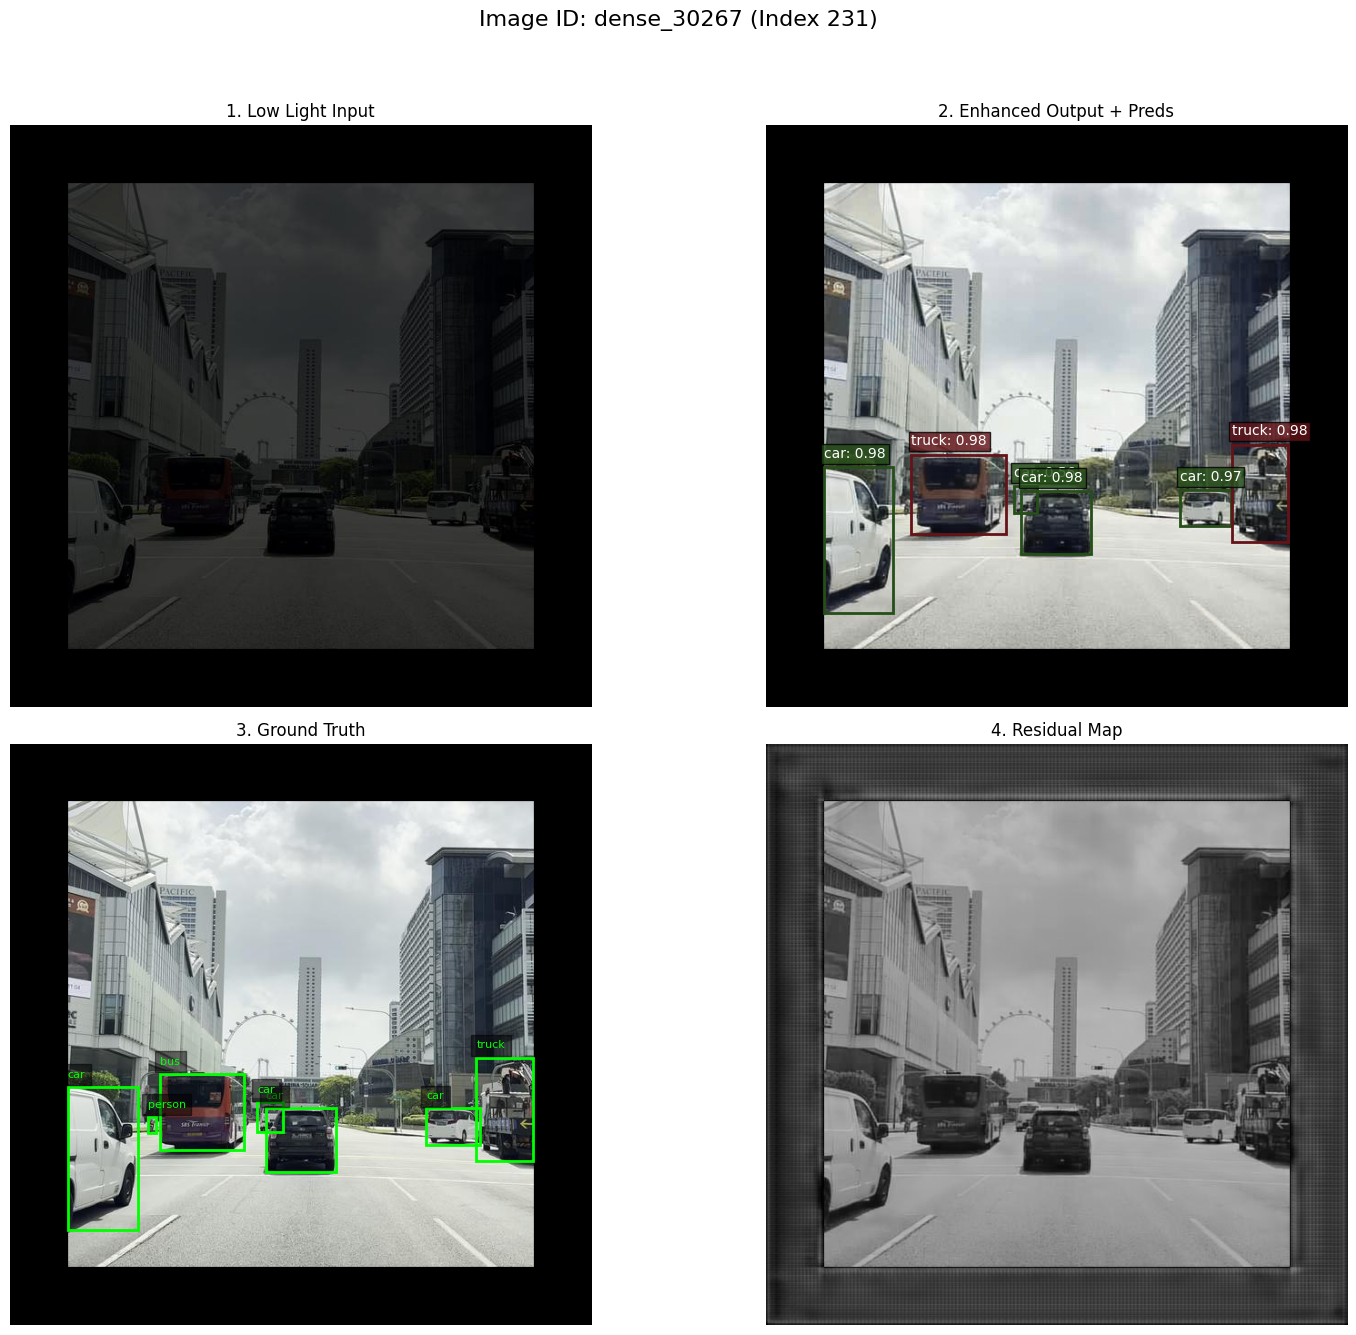

In [ ]:
def load_classes_as_dict(path):
    """
    Loads a class file of format:
    0: person
    1: bicycle
    ...
    And returns:
    {0: 'person', 1: 'bicycle', ...}
    """
    classes = {}
    
    with open(path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue   # skip empty lines
            
            # Split ONLY at the first ":" (safe even if names contain ":")
            idx, name = line.split(":", 1)
            idx = int(idx.strip())
            name = name.strip()
            
            classes[idx] = name
    
    return classes

from torchvision.ops import box_iou
import numpy as np
from post_processing.det_postprocess import Detections
from losses.llie_loss import psnr, ssim_metric
from tqdm import tqdm

# 1. Define Robust Precision/Recall Helper
def compute_precision_recall_robust(detections, gt_boxes, iou_thresh=0.5):
    """
    Robust calculation of P/R that handles empty or single-item tensors correctly.
    """
    # A. Prepare Prediction Boxes
    if len(detections) == 0:
        pred_boxes = torch.empty((0, 4))
    else:
        # Convert supervision numpy -> torch
        pred_boxes = torch.from_numpy(detections.xyxy).float()

    # B. Prepare GT Boxes
    gt_boxes = gt_boxes.cpu().float()
    pred_boxes = pred_boxes.cpu()

    # C. SAFETY: Force 2D shapes [N, 4] to prevent box_iou crash on single boxes
    if pred_boxes.dim() == 1: 
        pred_boxes = pred_boxes.unsqueeze(0)
    if gt_boxes.dim() == 1: 
        gt_boxes = gt_boxes.unsqueeze(0)

    # D. Edge Cases (Empty inputs)
    if len(gt_boxes) == 0:
        # If no GT, but we have preds -> Precision 0, Recall 0 (technically undefined)
        # If no GT, and no preds -> Perfect (1.0)
        return (0.0, 0.0) if len(pred_boxes) > 0 else (1.0, 1.0)
    
    if len(pred_boxes) == 0:
        # GT exists, but no preds -> Precision 0, Recall 0
        return 0.0, 0.0

    # E. Calculate IoU
    # box_iou requires (N,4) inputs
    ious = box_iou(pred_boxes, gt_boxes) 

    # F. Compute Metrics (Simple Greedy Matching)
    
    # Precision: What % of Predictions matched a GT?
    # For each Pred, did it hit ANY GT?
    max_iou_per_pred, _ = ious.max(dim=1)
    tp = (max_iou_per_pred >= iou_thresh).sum().item()
    fp = len(pred_boxes) - tp
    precision = tp / (tp + fp + 1e-6)

    # Recall: What % of GTs were detected?
    # For each GT, was it hit by ANY Pred?
    max_iou_per_gt, _ = ious.max(dim=0)
    tp_gt = (max_iou_per_gt >= iou_thresh).sum().item()
    fn = len(gt_boxes) - tp_gt
    recall = tp_gt / (tp_gt + fn + 1e-6)

    return precision, recall

def inference_visualization_mpl(model: torch.nn.Module, test_loader: torch.utils.data.DataLoader, class_names: dict):
    """
    Runs model inference, applies detection post-processing, and visualizes the 4 outputs 
    using a single Matplotlib figure with 4 subplots.
    """
    
    model.eval()
    device = next(model.parameters()).device
    
    print(f"--- Starting Visualization on Device: {device} ---")
    test_pbar = tqdm(test_loader, desc="Visualizing", leave=False)
    
    # Simple color map for visualization
    def get_color(cls_id, N): 
        # Generates a distinct color based on class ID
        r = (cls_id * 3 % 7 * 32 + 100) % 255 / 255.0
        g = (cls_id * 5 % 9 * 28 + 50) % 255 / 255.0
        b = (cls_id * 7 % 5 * 51 + 75) % 255 / 255.0
        return (r, g, b)

    def tensor_to_mpl(t: torch.Tensor) -> np.ndarray:
        # Clamp to [0, 1], move to CPU, HWC format (RGB) for Matplotlib
        return t.clamp(0, 1).cpu().numpy().transpose(1, 2, 0)

    with torch.no_grad():
        for batch_idx, batch_data in enumerate(test_pbar):
            
            low_imgs = batch_data['images_low'].to(device)
            
            # --- Model Forward Pass (Inference=True) ---
            det_out, llie_out, llie_residuals = model(low_imgs, inference=True)
            
            # --- Process Batch Image by Image ---
            for i in range(det_out.size(0)):
                
                # A. Detection Post-Processing
                
                # 1. Transpose to [N_boxes, C_data]
                preds_i = det_out[i].transpose(0, 1).contiguous() 

                # 2. Extract components
                boxes_xywh = preds_i[:, :4] # Model output is xywh
                cls_probs = preds_i[:, 4:]   # Class scores

                # 3. Get confidences and class indices
                confidences, class_indices = torch.max(cls_probs, dim=1)
                
                # 4. Convert coordinates
                boxes_xyxy = xywh2xyxy_tensor(boxes_xywh) 
                
                # 5. Filter by threshold
                CONF_THRESH = 0.75
                mask = confidences > CONF_THRESH
                
                if not mask.any(): 
                    detections = Detections.empty()
                else:
                    # 6. Create the final tensor [xyxy, conf, cls]
                    final_preds = torch.cat((
                        boxes_xyxy[mask], 
                        confidences[mask].unsqueeze(1), 
                        class_indices[mask].float().unsqueeze(1)
                    ), dim=1)
                    
                    # 7. Create Detections object
                    detections = Detections.from_yolo(final_preds)
                
                # B. Post-Processing: Rescale Boxes
                if len(detections) > 0:
                    detections = detections.with_nms(threshold=0.5)

                # C. Prepare Images for Display
                img_low_mpl = tensor_to_mpl(low_imgs[i])
                img_enhanced_mpl = tensor_to_mpl(llie_out[i])
                img_gt_mpl = tensor_to_mpl(batch_data['images_high'][i])
                residual_map = llie_residuals[i].mean(dim=0, keepdim=True).abs() 
                residual_vis_mpl = tensor_to_mpl(residual_map.repeat(3, 1, 1))

                # D. Visualization Plotting
                fig = plt.figure(figsize=(16, 14))
                fig.suptitle(f"Batch {batch_idx}, Image {i} Visualization", fontsize=16)
                
                # --- Plot 1: Low Light Input ---
                ax1 = fig.add_subplot(2, 2, 1)
                ax1.imshow(img_low_mpl)
                ax1.set_title('1. Low Light Input (I)')
                ax1.axis('off')
                
                # --- Plot 2: Enhanced Output with Detections ---
                ax2 = fig.add_subplot(2, 2, 2)
                ax2.imshow(img_enhanced_mpl)
                ax2.set_title('2. Enhanced Output (R) + Detections')
                ax2.axis('off')
                
                # Draw boxes on ax2
                if len(detections) > 0:
                    for box, _, conf, cls, _ in detections:
                        x1, y1, x2, y2 = box.astype(int)
                        
                        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, 
                                                 linewidth=2, 
                                                 edgecolor=get_color(int(cls), len(class_names)), 
                                                 facecolor='none')
                        ax2.add_patch(rect)
                        
                        label = f'{class_names.get(int(cls), "Unknown")}: {conf:.2f}'
                        ax2.text(x1, y1 - 10, label, color='white', 
                                 bbox={'facecolor': get_color(int(cls), len(class_names)), 
                                       'alpha': 0.8, 'pad': 2, 'edgecolor': 'none'})
                
                # --- Plot 3: Ground Truth High Light (G) ---
                ax3 = fig.add_subplot(2, 2, 3)
                ax3.imshow(img_gt_mpl)
                ax3.set_title('3. Ground Truth High Light (G)')
                ax3.axis('off')
                
                # --- NEW: PREPARE AND DRAW GT BOXES ---
                
                # 1. Setup variables
                all_batch_indices = batch_data['batch_idx'].to(device)
                all_bboxes = batch_data['bboxes'].to(device)
                all_cls = batch_data['cls'].to(device)
                
                mask_i = (all_batch_indices == i)
                gt_bboxes_xywh = all_bboxes[mask_i]
                gt_cls = all_cls[mask_i]
                
                pads = batch_data["padding_high"][i]
                
                # Define padded_image specifically for this loop iteration
                padded_image = batch_data['images_high'][i]
                padded_h, padded_w = padded_image.shape[1], padded_image.shape[2]

                # Initialize empty GT tensor on DEVICE
                gt_boxes_xyxy = torch.empty((0, 4), device=device)

                if gt_bboxes_xywh.numel() > 0:
                    # Convert normalized xywh -> absolute xyxy in PADDED space
                    boxes_abs = xywh2xyxy_tensor(gt_bboxes_xywh.clone())
                    boxes_abs[:, [0, 2]] *= padded_w
                    boxes_abs[:, [1, 3]] *= padded_h
                    
                    gt_boxes_xyxy = boxes_abs

                    # Draw boxes on Matplotlib
                    for j, box in enumerate(boxes_abs):
                        x1, y1, x2, y2 = box.int().tolist()
                        
                        rect = patches.Rectangle(
                            (x1, y1), x2 - x1, y2 - y1,
                            linewidth=2, edgecolor='lime', facecolor='none'
                        )
                        ax3.add_patch(rect)

                        cls_name = class_names.get(int(gt_cls[j]), "GT")
                        ax3.text(
                            x1, y1 - 10, cls_name,
                            color='lime', fontsize=8,
                            bbox={'facecolor': 'black', 'alpha': 0.5, 'pad': 2}
                        )
                
                # --- Plot 4: Residual Map (R - I) ---
                ax4 = fig.add_subplot(2, 2, 4)
                ax4.imshow(residual_vis_mpl)
                ax4.set_title('4. LLIE Residual Map (Magnitude)')
                ax4.axis('off')

                # --- Compute image metrics ---
                
                # Move GT image to DEVICE for PSNR/SSIM
                gt_image = batch_data['images_high'][i].to(device)

                img_psnr = psnr(
                    llie_out[i].unsqueeze(0),
                    gt_image.unsqueeze(0)
                ).item()

                img_ssim = ssim_metric(llie_out[i], gt_image)

                # *** FIX: Move GT boxes to CPU for compatibility with Detections (which are CPU/Numpy) ***
                precision_i, recall_i = compute_precision_recall(detections, gt_boxes_xyxy.cpu())
                map50_i = precision_i * recall_i 

                print(f"\n=== METRICS FOR THIS IMAGE ===")
                print(f"PSNR      : {img_psnr:.2f} dB")
                print(f"SSIM      : {img_ssim:.4f}")
                print(f"Precision : {precision_i:.3f}")
                print(f"Recall    : {recall_i:.3f}")
                print(f"mAP@50    : {map50_i:.3f}")

                plt.tight_layout(rect=[0, 0.03, 1, 0.95])
                plt.show() 
                
                # Stop after one image
                if batch_idx >= 0 and i >= 0: 
                    break 
            
            # Stop after one batch
            if batch_idx == 0:
                break 
                  
    print("--- Visualization Complete ---")

def xywh2xyxy_tensor(xywh:torch.Tensor):
    """
    Convert bounding box coordinates from (xywh) to (xyxy)
    """
    xy, wh = torch.chunk(xywh, 2, dim=-1)
    return torch.cat((xy - wh / 2, xy + wh / 2), dim=-1)

def visualize_random_sample(model: torch.nn.Module, test_loader: torch.utils.data.DataLoader, class_names: dict, rand_idx):
    """
    Picks ONE random image from the dataset, runs inference, and visualizes the result.
    """
    
    model.eval()
    device = next(model.parameters()).device
    dataset = test_loader.dataset
    
    # 1. Pick a Random Index
    # rand_idx = random.randint(0, len(dataset) - 1)
    print(f"--- Visualizing Random Sample Index: {rand_idx} ---")

    # 2. Fetch the single sample and Collate it into a batch of size 1
    # We use the loader's own collate_fn to ensure data structure matches exactly
    single_sample = dataset[rand_idx]
    batch_data = test_loader.collate_fn([single_sample])

    # 3. Simple color map & Helper
    def get_color(cls_id, N): 
        r = (cls_id * 3 % 7 * 32 + 100) % 255 / 255.0
        g = (cls_id * 5 % 9 * 28 + 50) % 255 / 255.0
        b = (cls_id * 7 % 5 * 51 + 75) % 255 / 255.0
        return (r, g, b)

    def tensor_to_mpl(t: torch.Tensor) -> np.ndarray:
        return t.clamp(0, 1).cpu().numpy().transpose(1, 2, 0)

    with torch.no_grad():
        # Move inputs to device
        low_imgs = batch_data['images_low'].to(device)
        
        # --- Model Forward Pass ---
        det_out, llie_out, llie_residuals = model(low_imgs, inference=True)
        
        # We know batch size is 1, so i is always 0
        i = 0 
        
        # A. Detection Post-Processing
        preds_i = det_out[i].transpose(0, 1).contiguous() 
        boxes_xywh = preds_i[:, :4]
        cls_probs = preds_i[:, 4:]  
        confidences, class_indices = torch.max(cls_probs, dim=1)
        
        boxes_xyxy = xywh2xyxy_tensor(boxes_xywh) 
        
        CONF_THRESH = 0.50 # You can adjust this
        mask = confidences > CONF_THRESH
        
        if not mask.any(): 
            detections = Detections.empty()
            print("No detections above threshold.")
        else:
            final_preds = torch.cat((
                boxes_xyxy[mask], 
                confidences[mask].unsqueeze(1), 
                class_indices[mask].float().unsqueeze(1)
            ), dim=1)
            detections = Detections.from_yolo(final_preds).with_nms(threshold=0.8)

        # B. Prepare Images
        img_low_mpl = tensor_to_mpl(low_imgs[i])
        img_enhanced_mpl = tensor_to_mpl(llie_out[i])
        img_gt_mpl = tensor_to_mpl(batch_data['images_high'][i])
        residual_map = llie_residuals[i].mean(dim=0, keepdim=True).abs() 
        residual_vis_mpl = tensor_to_mpl(residual_map.repeat(3, 1, 1))

        # C. Visualization Plotting
        fig = plt.figure(figsize=(16, 14))
        img_name = batch_data['im_id'][i]
        fig.suptitle(f"Image ID: {img_name} (Index {rand_idx})", fontsize=16)
        
        # Plot 1: Low Light
        ax1 = fig.add_subplot(2, 2, 1)
        ax1.imshow(img_low_mpl)
        ax1.set_title('1. Low Light Input')
        ax1.axis('off')
        
        # Plot 2: Enhanced + Detections
        ax2 = fig.add_subplot(2, 2, 2)
        ax2.imshow(img_enhanced_mpl)
        ax2.set_title('2. Enhanced Output + Preds')
        ax2.axis('off')
        
        if len(detections) > 0:
            for box, _, conf, cls, _ in detections:
                x1, y1, x2, y2 = box.astype(int)
                rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, 
                                         edgecolor=get_color(int(cls), len(class_names)), facecolor='none')
                ax2.add_patch(rect)
                label = f'{class_names.get(int(cls), "Unknown")}: {conf:.2f}'
                ax2.text(x1, y1 - 10, label, color='white', 
                         bbox={'facecolor': get_color(int(cls), len(class_names)), 'alpha': 0.8, 'pad': 2})
        
        # Plot 3: Ground Truth
        ax3 = fig.add_subplot(2, 2, 3)
        ax3.imshow(img_gt_mpl)
        ax3.set_title('3. Ground Truth')
        ax3.axis('off')
        
        # --- GT BOX LOGIC ---
        all_indices = batch_data['batch_idx'].to(device)
        all_bboxes = batch_data['bboxes'].to(device)
        all_cls = batch_data['cls'].to(device)
        
        mask_i = (all_indices == i) # Should be all True since batch size is 1
        gt_bboxes_xywh = all_bboxes[mask_i]
        gt_cls = all_cls[mask_i]
        
        padded_image = batch_data['images_high'][i]
        padded_h, padded_w = padded_image.shape[1], padded_image.shape[2]
        
        gt_boxes_xyxy = torch.empty((0, 4), device=device)

        if gt_bboxes_xywh.numel() > 0:
            boxes_abs = xywh2xyxy_tensor(gt_bboxes_xywh.clone())
            boxes_abs[:, [0, 2]] *= padded_w
            boxes_abs[:, [1, 3]] *= padded_h
            gt_boxes_xyxy = boxes_abs

            for j, box in enumerate(boxes_abs):
                x1, y1, x2, y2 = box.int().tolist()
                rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor='lime', facecolor='none')
                ax3.add_patch(rect)
                cls_name = class_names.get(int(gt_cls[j]), "GT")
                ax3.text(x1, y1 - 10, cls_name, color='lime', fontsize=8, bbox={'facecolor': 'black', 'alpha': 0.5})

        # Plot 4: Residual
        ax4 = fig.add_subplot(2, 2, 4)
        ax4.imshow(residual_vis_mpl)
        ax4.set_title('4. Residual Map')
        ax4.axis('off')

        # D. Metrics
        gt_image = batch_data['images_high'][i].to(device)
        img_psnr = psnr(llie_out[i].unsqueeze(0), gt_image.unsqueeze(0)).item()
        img_ssim = ssim_metric(llie_out[i], gt_image)
        if isinstance(img_ssim, torch.Tensor): img_ssim = img_ssim.item()
        
        # Robust Precision/Recall using the fixed function from before
        precision_i, recall_i = compute_precision_recall_robust(detections, gt_boxes_xyxy.cpu())
        map50_i = precision_i * recall_i 
        
        print(f"\n=== METRICS: Image {rand_idx} ===")
        print(f"PSNR      : {img_psnr:.2f}")
        print(f"SSIM      : {img_ssim:.4f}")
        print(f"Precision : {precision_i:.3f}")
        print(f"Recall    : {recall_i:.3f}")
        print(f"mAP@50    : {map50_i:.3f}")

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

# Usage:
# visualize_random_sample(model, test_loader, CLASSES_TO_DETECT)
model = IllumiNet_b5_ARB(back_use_arb=False, dec_arb=False)

# checkpoint_path = 'final_baseline_epoch60.pt'

# checkpoint_path = r'C:\Users\Sistem Cerdas Five\Desktop\vian\afre\lesgo\New folder\run_weights_NEWEST\best_baseline_mAP.pt'
checkpoint_path = r'C:\Users\Sistem Cerdas Five\Desktop\vian\afre\lesgo\New folder\final_dynamic-baseline_epoch60.pt'
checkpoint = torch.load(checkpoint_path, map_location=torch.device('cpu'))

if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
    # Case A: You saved {'epoch': ..., 'model_state_dict': ...}
    print("Loading from full checkpoint dictionary...")
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    # Case B: You saved model.state_dict() directly
    print("Loading direct state dictionary...")
    model.load_state_dict(checkpoint)

model.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
print("Model loaded successfully!")

CLASSES_TO_DETECT = load_classes_as_dict(CLASSES_FILE)
# inference_visualization_mpl(model=model, test_loader=test_loader, class_names=CLASSES_TO_DETECT)
visualize_random_sample(model=model, test_loader=test_loader, class_names=CLASSES_TO_DETECT, rand_idx=231)

In [ ]:
from torchvision.ops import nms
# import torch
# from tqdm import tqdm

from torchvision.ops import box_iou

def compute_pr_tensor(pred_boxes: torch.Tensor, gt_boxes: torch.Tensor, iou_thresh=0.5):
    """
    Pure-tensor calculation of Precision and Recall.
    No Detections objects or numpy arrays required.
    """
    # Move everything to CPU safely
    pred_boxes = pred_boxes.cpu().float()
    gt_boxes = gt_boxes.cpu().float()
    
    # SAFETY: Force 2D shapes [N, 4]
    if pred_boxes.dim() == 1: pred_boxes = pred_boxes.unsqueeze(0)
    if gt_boxes.dim() == 1: gt_boxes = gt_boxes.unsqueeze(0)

    if len(gt_boxes) == 0:
        return (0.0, 0.0) if len(pred_boxes) > 0 else (1.0, 1.0)
    if len(pred_boxes) == 0:
        return 0.0, 0.0

    # Calculate IoU
    ious = box_iou(pred_boxes, gt_boxes) 

    # Precision
    max_iou_per_pred, _ = ious.max(dim=1)
    tp = (max_iou_per_pred >= iou_thresh).sum().item()
    fp = len(pred_boxes) - tp
    precision = tp / (tp + fp + 1e-6)

    # Recall
    max_iou_per_gt, _ = ious.max(dim=0)
    tp_gt = (max_iou_per_gt >= iou_thresh).sum().item()
    fn = len(gt_boxes) - tp_gt
    recall = tp_gt / (tp_gt + fn + 1e-6)

    return precision, recall

def find_best_nms_threshold(model, val_loader, device, conf_thresh=0.01):
    """
    Tests multiple NMS IoU thresholds simultaneously to find the optimal balance
    for occluded/overlapping objects.
    """
    model.eval()
    
    # The thresholds we want to test (0.4 is strict, 0.8 allows heavy overlap)
    nms_thresholds = [0.40, 0.50, 0.60, 0.70, 0.80]
    
    # Dictionary to hold the running metrics for each threshold
    results = {nms_val: {'precision': 0.0, 'recall': 0.0, 'map50': 0.0, 'count': 0} for nms_val in nms_thresholds}
    
    print(f"--- Running NMS Sweep on Device: {device} ---")
    
    with torch.no_grad():
        for batch_data in tqdm(val_loader, desc="Testing NMS Variants"):
            low_imgs = batch_data['images_low'].to(device)
            B, _, H, W = low_imgs.shape
            
            # 1. Forward Pass
            with torch.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                det_out, _, _ = model(low_imgs, inference=True)
            
            for b in range(B):
                # Extract raw predictions for this image
                p = det_out[b].permute(1, 0)
                boxes_xywh = p[:, :4]
                cls_scores, labels = p[:, 4:].max(dim=1)
                
                # Convert xywh to xyxy
                pred_xy = boxes_xywh[:, :2]
                pred_wh = boxes_xywh[:, 2:]
                boxes_xyxy = torch.cat((pred_xy - pred_wh / 2, pred_xy + pred_wh / 2), dim=1)
                
                # Filter by base confidence
                mask = cls_scores > conf_thresh
                base_boxes, base_scores = boxes_xyxy[mask], cls_scores[mask]
                
                # Extract Ground Truth for this image
                gt_mask = batch_data['batch_idx'].to(device) == b
                gt_boxes_xywh = batch_data['bboxes'].to(device)[gt_mask]
                
                if len(gt_boxes_xywh) > 0:
                    gt_xy = gt_boxes_xywh[:, :2]
                    gt_wh = gt_boxes_xywh[:, 2:]
                    gt_boxes_xyxy = torch.cat((gt_xy - gt_wh / 2, gt_xy + gt_wh / 2), dim=1)
                    gt_boxes_xyxy[:, [0, 2]] *= W
                    gt_boxes_xyxy[:, [1, 3]] *= H
                else:
                    gt_boxes_xyxy = torch.empty((0, 4), device=device)
                
                # 2. Test EVERY NMS threshold on these exact same raw boxes
                for nms_val in nms_thresholds:
                    if len(base_boxes) > 0:
                        keep = nms(base_boxes, base_scores, iou_threshold=nms_val)
                        final_boxes = base_boxes[keep]
                    else:
                        final_boxes = base_boxes
                        
                    # Compute P/R using your robust manual function
                    prec, rec = compute_pr_tensor(final_boxes, gt_boxes_xyxy, iou_thresh=0.5)
                    
                    results[nms_val]['precision'] += prec
                    results[nms_val]['recall'] += rec
                    results[nms_val]['map50'] += (prec * rec)
                    results[nms_val]['count'] += 1

    # 3. Print the Final Table
    print("\n" + "="*55)
    print(f"{'NMS Threshold':<15} | {'Precision':<10} | {'Recall':<10} | {'mAP@50':<10}")
    print("="*55)
    
    for nms_val in nms_thresholds:
        count = results[nms_val]['count']
        avg_p = results[nms_val]['precision'] / count if count > 0 else 0
        avg_r = results[nms_val]['recall'] / count if count > 0 else 0
        avg_map = results[nms_val]['map50'] / count if count > 0 else 0
        
        print(f"{nms_val:<15.2f} | {avg_p:<10.4f} | {avg_r:<10.4f} | {avg_map:<10.4f}")
    print("="*55)

# Run it!
find_best_nms_threshold(baseline, test_loader, DEVICE)

--- Running NMS Sweep on Device: cuda ---


Testing NMS Variants: 100%|██████████| 38/38 [00:03<00:00, 11.24it/s]


NMS Threshold   | Precision  | Recall     | mAP@50    
0.40            | 0.6827     | 0.7938     | 0.5562    
0.50            | 0.6720     | 0.8042     | 0.5532    
0.60            | 0.6650     | 0.8073     | 0.5495    
0.70            | 0.6646     | 0.8136     | 0.5513    
0.80            | 0.6704     | 0.8179     | 0.5593    


In [ ]:
# class ModelEvaluator:
#     def __init__(self, test_loader, device):
#         self.test_loader = test_loader
#         self.device = device
    
#     def evaluate(self, model, weight_path, model_name="Unknown"):
#         # 1. Load Weights
#         print(f"Loading weights for {model_name} from: {weight_path}")
#         try:
#             checkpoint = torch.load(weight_path, map_location=self.device)
#             # Handle if weights are in 'model_state_dict' or just the dict directly
#             state_dict = checkpoint['model_state_dict'] if 'model_state_dict' in checkpoint else checkpoint
#             model.load_state_dict(state_dict)
#         except Exception as e:
#             print(f"Error loading {weight_path}: {e}")
#             return None

#         model.to(self.device)
#         model.eval()
        
#         # Metrics Accumulators
#         metrics = {
#             'psnr': [],
#             'ssim': [],
#             'precision': [],
#             'recall': [],
#             'map50': []
#         }
        
#         pbar = tqdm(self.test_loader, desc=f"Eval {model_name}", leave=True)
        
#         with torch.no_grad():
#             for batch_data in pbar:
#                 low_imgs = batch_data['images_low'].to(self.device)
                
#                 # Inference
#                 det_out, llie_out, _ = model(low_imgs, inference=True)
                
#                 # --- Per Image Processing in Batch ---
#                 for i in range(det_out.size(0)):
#                     # ================================
#                     # 1. IMAGE METRICS (PSNR / SSIM)
#                     # ================================
#                     gt_image = batch_data['images_high'][i].to(self.device)
#                     enhanced_image = llie_out[i]
                    
#                     # PSNR
#                     val_psnr = psnr(enhanced_image.unsqueeze(0), gt_image.unsqueeze(0)).item()
#                     metrics['psnr'].append(val_psnr)
                    
#                     # SSIM
#                     val_ssim = ssim_metric(enhanced_image, gt_image) # Assumes input is (C, H, W) or (1, C, H, W)
#                     # Handle if ssim returns tensor
#                     if isinstance(val_ssim, torch.Tensor):
#                         val_ssim = val_ssim.item()
#                     metrics['ssim'].append(val_ssim)

#                     # ================================
#                     # 2. DETECTION METRICS
#                     # ================================
                    
#                     # --- PREPARE PREDICTIONS ---
#                     preds_i = det_out[i].transpose(0, 1).contiguous()
#                     boxes_xywh = preds_i[:, :4]
#                     cls_probs = preds_i[:, 4:]
#                     confidences, class_indices = torch.max(cls_probs, dim=1)
                    
#                     boxes_xyxy = xywh2xyxy_tensor(boxes_xywh)
                    
#                     CONF_THRESH = 0.50 # Standard eval threshold, adjust if needed
#                     mask = confidences > CONF_THRESH
                    
#                     if not mask.any():
#                         detections = Detections.empty()
#                     else:
#                         final_preds = torch.cat((
#                             boxes_xyxy[mask], 
#                             confidences[mask].unsqueeze(1), 
#                             class_indices[mask].float().unsqueeze(1)
#                         ), dim=1)
#                         detections = Detections.from_yolo(final_preds)
#                         detections = detections.with_nms(threshold=0.5)

#                     # --- PREPARE GROUND TRUTH ---
#                     all_indices = batch_data['batch_idx'].to(self.device)
#                     all_bboxes = batch_data['bboxes'].to(self.device)
#                     all_cls = batch_data['cls'].to(self.device)
                    
#                     # Filter for current image
#                     mask_i = (all_indices == i)
#                     gt_bboxes_xywh = all_bboxes[mask_i]
                    
#                     padded_image = batch_data['images_high'][i]
#                     padded_h, padded_w = padded_image.shape[1], padded_image.shape[2]
                    
#                     gt_boxes_xyxy = torch.empty((0, 4), device=self.device)
                    
#                     if gt_bboxes_xywh.numel() > 0:
#                         # Normalize -> Absolute Padded Coordinates
#                         boxes_abs = xywh2xyxy_tensor(gt_bboxes_xywh.clone())
#                         boxes_abs[:, [0, 2]] *= padded_w
#                         boxes_abs[:, [1, 3]] *= padded_h
#                         gt_boxes_xyxy = boxes_abs

#                     # --- COMPUTE DETECTION METRICS ---
#                     # Move to CPU for compatibility if using supervision or numpy based IoU
#                     prec, rec = compute_precision_recall_robust(detections, gt_boxes_xyxy.cpu())
                    
#                     metrics['precision'].append(prec)
#                     metrics['recall'].append(rec)
#                     metrics['map50'].append(prec * rec) # Simple mAP estimation

#         # Calculate Averages
#         summary = {k: np.mean(v) for k, v in metrics.items()}
#         print(f"Results {model_name}: {summary}")
#         return summary

import torch
import numpy as np
from tqdm import tqdm
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from torchvision.ops import nms



class ModelEvaluator:
    def __init__(self, test_loader, device, min_area=None):
        self.test_loader = test_loader
        self.device = device
        
        # PROFESSOR's FILTER: Minimum bounding box area (in pixels) to evaluate.
        # Set to 1024 to ignore all COCO "Small" objects. Set to None to evaluate everything.
        self.min_area = min_area 
        
        # Initialize torchmetrics strictly for IoU = 0.50!
        # This forces map, map_small, map_medium, and map_large to ALL be evaluated at 50% overlap.
        self.map_metric = MeanAveragePrecision(
            box_format='xyxy',
            iou_type='bbox',
            iou_thresholds=[0.5],
            max_detection_thresholds=[10, 100, 500]
        ).to(device)
    
    def evaluate(self, model, weight_path, model_name="Unknown"):
        print(f"\nLoading weights for {model_name} from: {weight_path}")
        try:
            checkpoint = torch.load(weight_path, map_location=self.device)
            state_dict = checkpoint['model_state_dict'] if 'model_state_dict' in checkpoint else checkpoint
            model.load_state_dict(state_dict)
        except Exception as e:
            print(f"Error loading {weight_path}: {e}")
            return None

        model.to(self.device)
        model.eval()
        
        self.map_metric.reset()
        
        metrics = {'psnr': [], 'ssim': []}
        
        pbar = tqdm(self.test_loader, desc=f"Eval {model_name}", leave=True)
        
        with torch.no_grad():
            with torch.autocast(device_type=self.device.type, enabled=(self.device.type == 'cuda')):
                for batch_data in pbar:
                    low_imgs = batch_data['images_low'].to(self.device)
                    high_imgs = batch_data['images_high'].to(self.device)
                    
                    B, _, H, W = low_imgs.shape 

                    # Inference
                    det_out, llie_out, _ = model(low_imgs, inference=True)
                    
                    preds, targets = [], []

                    for i in range(B):
                        # ================================
                        # 1. IMAGE METRICS (PSNR / SSIM)
                        # ================================
                        gt_image = high_imgs[i]
                        enhanced_image = llie_out[i]
                        
                        val_psnr = psnr(enhanced_image.unsqueeze(0), gt_image.unsqueeze(0)).item()
                        metrics['psnr'].append(val_psnr)
                        
                        val_ssim = ssim_metric(enhanced_image, gt_image) 
                        if isinstance(val_ssim, torch.Tensor):
                            val_ssim = val_ssim.item()
                        metrics['ssim'].append(val_ssim)

                        # ================================
                        # 2. DETECTION METRICS
                        # ================================
                        
                        # --- PREDICTIONS ---
                        p = det_out[i].transpose(0, 1).contiguous()
                        boxes_xywh = p[:, :4]
                        cls_probs = p[:, 4:]
                        confidences, class_indices = torch.max(cls_probs, dim=1)
                        
                        boxes_xyxy = xywh2xyxy_tensor(boxes_xywh)
                        
                        # Keep confidence low (0.001) for accurate PR Curve generation
                        mask = confidences > 0.5
                        pred_boxes = boxes_xyxy[mask]
                        pred_scores = confidences[mask]
                        pred_labels = class_indices[mask]
                        
                        if len(pred_boxes) > 0:
                            # Apply your proven NMS threshold
                            keep = nms(pred_boxes, pred_scores, 0.45)
                            pred_boxes = pred_boxes[keep]
                            pred_scores = pred_scores[keep]
                            pred_labels = pred_labels[keep]
                            
                            # PROFESSOR'S FILTER (Predictions)
                            if self.min_area is not None:
                                areas = (pred_boxes[:, 2] - pred_boxes[:, 0]) * (pred_boxes[:, 3] - pred_boxes[:, 1])
                                valid_mask = areas >= self.min_area
                                pred_boxes = pred_boxes[valid_mask]
                                pred_scores = pred_scores[valid_mask]
                                pred_labels = pred_labels[valid_mask]

                        preds.append({
                            "boxes": pred_boxes,
                            "scores": pred_scores,
                            "labels": pred_labels
                        })

                        # --- GROUND TRUTH ---
                        all_indices = batch_data['batch_idx'].to(self.device)
                        all_bboxes = batch_data['bboxes'].to(self.device)
                        all_cls = batch_data['cls'].to(self.device)
                        
                        mask_i = (all_indices == i)
                        gt_bboxes_xywh = all_bboxes[mask_i]
                        gt_labels = all_cls[mask_i]
                        
                        gt_boxes_xyxy = torch.empty((0, 4), device=self.device)
                        
                        if gt_bboxes_xywh.numel() > 0:
                            # Normalize -> Absolute Coordinates
                            boxes_abs = xywh2xyxy_tensor(gt_bboxes_xywh.clone())
                            boxes_abs[:, [0, 2]] *= W
                            boxes_abs[:, [1, 3]] *= H
                            gt_boxes_xyxy = boxes_abs
                            
                            # PROFESSOR'S FILTER (Ground Truth)
                            if self.min_area is not None:
                                areas = (gt_boxes_xyxy[:, 2] - gt_boxes_xyxy[:, 0]) * (gt_boxes_xyxy[:, 3] - gt_boxes_xyxy[:, 1])
                                valid_mask = areas >= self.min_area
                                gt_boxes_xyxy = gt_boxes_xyxy[valid_mask]
                                gt_labels = gt_labels[valid_mask]

                        targets.append({
                            "boxes": gt_boxes_xyxy,
                            "labels": gt_labels
                        })

                    # Update torchmetrics object with batch data
                    self.map_metric.update(preds, targets)

        # Compute final detection metrics
        map_results = self.map_metric.compute()
        
        # Build Summary Dictionary
        summary = {
            'psnr': np.mean(metrics['psnr']),
            'ssim': np.mean(metrics['ssim']),
            'mAP@50_Total': map_results['map'].item(),       # This is strictly @50 now!
            'mAP@50_Small': map_results['map_small'].item(),
            'mAP@50_Medium': map_results['map_medium'].item(),
            'mAP@50_Large': map_results['map_large'].item()
        }
        
        # Clean up missing data (-1 means no objects of that size were present)
        for k, v in summary.items():
            if v == -1: summary[k] = 0.0

        print(f"\n--- Results for {model_name} ---")
        for key, value in summary.items():
            print(f"{key:>15}: {value:.4f}")
            
        return summary


class GranularModelEvaluator:
    # Added class_names dictionary so it prints "Car" instead of "Class 2"
    def __init__(self, test_loader, device, min_area=None, class_names=None):
        self.test_loader = test_loader
        self.device = device
        self.min_area = min_area 
        self.class_names = class_names or {} # e.g., {0: 'person', 1: 'bicycle', 2: 'car'}
        
        self.map_metric = MeanAveragePrecision(
            box_format='xyxy',
            iou_type='bbox',
            iou_thresholds=[0.5],
            max_detection_thresholds=[10, 100, 500],
            class_metrics=True  # <--- THIS UNLOCKS CLASS-SPECIFIC MAP
        ).to(device)
    
    def evaluate(self, model, weight_path, model_name="Unknown"):
        print(f"\nLoading weights for {model_name} from: {weight_path}")
        try:
            checkpoint = torch.load(weight_path, map_location=self.device)
            state_dict = checkpoint['model_state_dict'] if 'model_state_dict' in checkpoint else checkpoint
            model.load_state_dict(state_dict)
        except Exception as e:
            print(f"Error loading {weight_path}: {e}")
            return None

        model.to(self.device)
        model.eval()
        self.map_metric.reset()
        
        # New Granular Dictionaries
        metrics = {
            'psnr': {'all': [], 'light': [], 'moderate': [], 'dense': []},
            'ssim': {'all': [], 'light': [], 'moderate': [], 'dense': []}
        }
        
        pbar = tqdm(self.test_loader, desc=f"Eval {model_name}", leave=True)
        
        with torch.no_grad():
            with torch.autocast(device_type=self.device.type, enabled=(self.device.type == 'cuda')):
                for batch_data in pbar:
                    low_imgs = batch_data['images_low'].to(self.device)
                    high_imgs = batch_data['images_high'].to(self.device)
                    B, _, H, W = low_imgs.shape 

                    det_out, llie_out, _ = model(low_imgs, inference=True)
                    preds, targets = [], []

                    for i in range(B):
                        # --- DETERMINE SCENE DENSITY ---
                        # Count the number of Ground Truth boxes before filtering
                        all_indices = batch_data['batch_idx'].to(self.device)
                        mask_i = (all_indices == i)
                        num_objects = mask_i.sum().item()
                        
                        # Tweak these thresholds based on your dataset!
                        if num_objects <= 10:
                            density = 'light'
                        elif num_objects <= 30:
                            density = 'moderate'
                        else:
                            density = 'dense'

                        # ================================
                        # 1. IMAGE METRICS (PSNR / SSIM)
                        # ================================
                        gt_image = high_imgs[i]
                        enhanced_image = llie_out[i]
                        
                        val_psnr = psnr(enhanced_image.unsqueeze(0), gt_image.unsqueeze(0)).item()
                        val_ssim = ssim_metric(enhanced_image, gt_image) 
                        if isinstance(val_ssim, torch.Tensor): val_ssim = val_ssim.item()
                        
                        metrics['psnr']['all'].append(val_psnr)
                        metrics['psnr'][density].append(val_psnr)
                        metrics['ssim']['all'].append(val_ssim)
                        metrics['ssim'][density].append(val_ssim)

                        # ================================
                        # 2. DETECTION METRICS
                        # ================================
                        p = det_out[i].transpose(0, 1).contiguous()
                        boxes_xywh = p[:, :4]
                        cls_probs = p[:, 4:]
                        confidences, class_indices = torch.max(cls_probs, dim=1)
                        boxes_xyxy = xywh2xyxy_tensor(boxes_xywh)
                        
                        mask = confidences > 0.001
                        pred_boxes, pred_scores, pred_labels = boxes_xyxy[mask], confidences[mask], class_indices[mask]
                        
                        if len(pred_boxes) > 0:
                            # Strict NMS 0.45 to prevent duplicate box penalties
                            keep = nms(pred_boxes, pred_scores, 0.45)
                            pred_boxes, pred_scores, pred_labels = pred_boxes[keep], pred_scores[keep], pred_labels[keep]
                            
                            if self.min_area is not None:
                                areas = (pred_boxes[:, 2] - pred_boxes[:, 0]) * (pred_boxes[:, 3] - pred_boxes[:, 1])
                                valid_mask = areas >= self.min_area
                                pred_boxes, pred_scores, pred_labels = pred_boxes[valid_mask], pred_scores[valid_mask], pred_labels[valid_mask]

                        preds.append({"boxes": pred_boxes, "scores": pred_scores, "labels": pred_labels})

                        # Ground Truth Processing
                        gt_bboxes_xywh = batch_data['bboxes'][mask_i].to(self.device)
                        gt_labels = batch_data['cls'][mask_i].to(self.device)
                        gt_boxes_xyxy = torch.empty((0, 4), device=self.device)
                        
                        if gt_bboxes_xywh.numel() > 0:
                            boxes_abs = xywh2xyxy_tensor(gt_bboxes_xywh.clone())
                            boxes_abs[:, [0, 2]] *= W
                            boxes_abs[:, [1, 3]] *= H
                            gt_boxes_xyxy = boxes_abs
                            
                            if self.min_area is not None:
                                areas = (gt_boxes_xyxy[:, 2] - gt_boxes_xyxy[:, 0]) * (gt_boxes_xyxy[:, 3] - gt_boxes_xyxy[:, 1])
                                valid_mask = areas >= self.min_area
                                gt_boxes_xyxy, gt_labels = gt_boxes_xyxy[valid_mask], gt_labels[valid_mask]

                        targets.append({"boxes": gt_boxes_xyxy, "labels": gt_labels})

                    self.map_metric.update(preds, targets)

        # ================================
        # 3. COMPUTE AND FORMAT RESULTS
        # ================================
        map_results = self.map_metric.compute()
        
        # Safe mean calculator
        def safe_mean(lst): return np.mean(lst) if len(lst) > 0 else 0.0

        summary = {
            'psnr_mean': safe_mean(metrics['psnr']['all']),
            'ssim_mean': safe_mean(metrics['ssim']['all']),
            'psnr_light': safe_mean(metrics['psnr']['light']),
            'psnr_moderate': safe_mean(metrics['psnr']['moderate']),
            'psnr_dense': safe_mean(metrics['psnr']['dense']),
            'mAP@50_Total': map_results['map'].item(),
            'mAP@50_Small': map_results.get('map_small', torch.tensor(0.0)).item(),
            'mAP@50_Medium': map_results.get('map_medium', torch.tensor(0.0)).item(),
            'mAP@50_Large': map_results.get('map_large', torch.tensor(0.0)).item()
        }
        
        # Clean up -1 scores (torchmetrics returns -1 if no objects of that size exist)
        for k in ['mAP@50_Small', 'mAP@50_Medium', 'mAP@50_Large']:
            if summary[k] == -1.0: summary[k] = 0.0

        # Extract Top 3 and Bottom 3 Classes
        top_3_str, bottom_3_str = "N/A", "N/A"
        if 'map_per_class' in map_results and 'classes' in map_results:
            class_maps = map_results['map_per_class'].tolist()
            class_ids = map_results['classes'].tolist()
            
            # Pair them up, ignore -1 (classes not present in test set)
            valid_classes = [(self.class_names.get(int(cid), f"Class {int(cid)}"), score) 
                             for cid, score in zip(class_ids, class_maps) if score != -1]
            
            valid_classes.sort(key=lambda x: x[1]) # Sort ascending
            
            if len(valid_classes) > 0:
                bottom_3 = valid_classes[:3]
                top_3 = valid_classes[-3:]
                top_3.reverse() # Highest first
                
                top_3_str = ", ".join([f"{name} ({score:.4f})" for name, score in top_3])
                bottom_3_str = ", ".join([f"{name} ({score:.4f})" for name, score in bottom_3])
                
        summary['Top_3_Classes'] = top_3_str
        summary['Bottom_3_Classes'] = bottom_3_str

        print(f"\n--- Results for {model_name} ---")
        for key, value in summary.items():
            if isinstance(value, float):
                print(f"{key:>18}: {value:.4f}")
            else:
                print(f"{key:>18}: {value}")
            
        return summary
    
    
model_weight_paths = {
    "default_final": 'dynamic-results/final_dynamic-baseline_epoch60.pt',
    'default_best': 'dynamic-results/best_dynamic-baseline_mAP.pt',
    
    'backARB_decDef_final':  'dynamic-results/final_dynamic-backARB_epoch60.pt',
    'backARB_decDef_best' : 'dynamic-results/best_dynamic-backARB_mAP.pt',
    
    'decARB_final' : 'dynamic-results/final_dynamic-decARB_epoch60.pt',
    'decARB_best' : 'dynamic-results/best_dynamic-decARB_mAP.pt',
    
    'bothARB_final' : 'dynamic-results/final_dynamic-bothARB_epoch60.pt',
    'bothARB_best' : 'dynamic-results/best_dynamic-bothARB_mAP.pt'
}

default_mod = IllumiNet_b5_ARB(back_use_arb=False, dec_arb=False)
backARB_decDef_mod = IllumiNet_b5_ARB(back_use_arb=True, dec_arb=False)
backDef_decARB_mod = IllumiNet_b5_ARB(back_use_arb=False, dec_arb=True)
bothARB_mod = IllumiNet_b5_ARB(back_use_arb=True, dec_arb=True)


configurations = [
    ("Default (Final)",       default_mod,        "default_final"),
    ("Default (Best)",        default_mod,        "default_best"),
    
    ("BackARB (Final)",       backARB_decDef_mod, "backARB_decDef_final"),
    ("BackARB (Best)",        backARB_decDef_mod, "backARB_decDef_best"),
    
    ("DecARB (Final)",        backDef_decARB_mod, "decARB_final"),
    ("DecARB (Best)",         backDef_decARB_mod, "decARB_best"),
    
    ("BothARB (Final)",       bothARB_mod,        "bothARB_final"),
    ("BothARB (Best)",        bothARB_mod,        "bothARB_best"),
]

evaluator = ModelEvaluator(test_loader, device, min_area=None)
# evaluator = GranularModelEvaluator(test_loader, device, min_area=1024, class_names=CLASSES_TO_DETECT)

results_table = []

print("Starting Full Evaluation Benchmark...")
print("="*60)

for nice_name, model_obj, weight_key in configurations:
    weight_file = model_weight_paths.get(weight_key)
    
    if not weight_file:
        print(f"Skipping {nice_name}: Key {weight_key} not found in path dict.")
        continue
        
    # Run Eval
    res = evaluator.evaluate(model_obj, weight_file, model_name=nice_name)
    
    if res:
        res['Model'] = nice_name
        res['Weights'] = weight_file
        results_table.append(res)

# 6. Display Final DataFrame
print("\n" + "="*60)
print("FINAL BENCHMARK RESULTS")
print("="*60)

if results_table:
    df_results = pd.DataFrame(results_table)
    
    # Reorder columns for readability
    # cols = ['Model', 'map50', 'precision', 'recall', 'psnr', 'ssim', 'Weights']
    cols = ['Model', 'mAP@50_Total', "mAP@50_Small", 'mAP@50_Medium', 'mAP@50_Large', 'psnr', 'ssim', 'Weights']
    
    df_results = df_results[cols]
    
    # Round for display
    print(df_results.round(4).to_string(index=False))
else:
    print("No results generated.")

Backbone ARB:  False
Decoder ARB False
Initializing nano params
NO ARB in Backbone
Night Dec initalized
Initializing nano params


C:\Users\Sistem Cerdas Five\AppData\Local\Temp\ipykernel_28108\768348262.py:147: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(weight_path, map_locat

Initializing nano params
✅ Loaded 162 layers into Backbone.
Missing keys: 0 | Unexpected keys: 0
✅ Loaded 108 layers into Neck.
Missing keys: 0 | Unexpected keys: 0
✅ Loaded 85 layers into Head.
Missing keys: 0 | Unexpected keys: 0
pretrain weights loaded
Backbone ARB:  True
Decoder ARB False
Initializing nano params
ARB Backbone Initialized
Night Dec initalized
Initializing nano params
Initializing nano params
✅ Loaded 162 layers into Backbone.
Missing keys: 72 | Unexpected keys: 0
✅ Loaded 108 layers into Neck.
Missing keys: 0 | Unexpected keys: 0
✅ Loaded 85 layers into Head.
Missing keys: 0 | Unexpected keys: 0
pretrain weights loaded
Backbone ARB:  False
Decoder ARB True
Initializing nano params
NO ARB in Backbone
ARB LLIE Decoder Initialized
Initializing nano params
Initializing nano params
✅ Loaded 162 layers into Backbone.
Missing keys: 0 | Unexpected keys: 0
✅ Loaded 108 layers into Neck.
Missing keys: 0 | Unexpected keys: 0
✅ Loaded 85 layers into Head.
Missing keys: 0 | Unex

Eval Default (Final): 100%|██████████| 38/38 [00:28<00:00,  1.34it/s]



--- Results for Default (Final) ---
           psnr: 29.4240
           ssim: 0.9333
   mAP@50_Total: 0.1641
   mAP@50_Small: 0.1179
  mAP@50_Medium: 0.2535
   mAP@50_Large: 0.3543

Loading weights for Default (Best) from: dynamic-results/best_dynamic-baseline_mAP.pt


...


--- Results for DecARB (Best) ---
           psnr: 30.2370
           ssim: 0.9323
   mAP@50_Total: 0.1520
   mAP@50_Small: 0.1052
  mAP@50_Medium: 0.2625
   mAP@50_Large: 0.3433

Loading weights for BothARB (Final) from: dynamic-results/final_dynamic-bothARB_epoch60.pt


Eval BothARB (Final): 100%|██████████| 38/38 [00:31<00:00,  1.22it/s]



--- Results for BothARB (Final) ---
           psnr: 31.1311
           ssim: 0.9374
   mAP@50_Total: 0.1344
   mAP@50_Small: 0.0957
  mAP@50_Medium: 0.2376
   mAP@50_Large: 0.3181

Loading weights for BothARB (Best) from: dynamic-results/best_dynamic-bothARB_mAP.pt


Eval BothARB (Best): 100%|██████████| 38/38 [00:31<00:00,  1.21it/s]



--- Results for BothARB (Best) ---
           psnr: 30.7945
           ssim: 0.9357
   mAP@50_Total: 0.1514
   mAP@50_Small: 0.1122
  mAP@50_Medium: 0.2672
   mAP@50_Large: 0.3191

FINAL BENCHMARK RESULTS
          Model  mAP@50_Total  mAP@50_Small  mAP@50_Medium  mAP@50_Large    psnr   ssim                                           Weights
Default (Final)        0.1641        0.1179         0.2535        0.3543 29.4240 0.9333 dynamic-results/final_dynamic-baseline_epoch60.pt
 Default (Best)        0.1625        0.1136         0.2409        0.3779 28.2858 0.9247      dynamic-results/best_dynamic-baseline_mAP.pt
BackARB (Final)        0.1547        0.1306         0.2337        0.3538 31.1679 0.9374  dynamic-results/final_dynamic-backARB_epoch60.pt
 BackARB (Best)        0.1609        0.1314         0.2313        0.3542 30.4372 0.9347       dynamic-results/best_dynamic-backARB_mAP.pt
 DecARB (Final)        0.1522        0.1164         0.2337        0.3285 31.2206 0.9372   dynamic-result